Link the schema here for reference

Begin

In [291]:

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import astropy.units as u

from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.nddata import Cutout2D
from astropy.table import QTable
from astropy.stats import SigmaClip

from astroquery.gaia import Gaia

from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
from photutils.centroids import centroid_quadratic

from synphot import Observation, SpectralElement, SourceSpectrum, BlackBodyNorm1D
from synphot import units as su

from spextra import Spextrum


In [292]:
# create the master calibration table

cal_table = QTable()

# dao params
cal_table["x_centroid"] = [] * u.pix
cal_table["y_centroid"] = [] * u.pix
cal_table["oiii_raw_sum"] = [] * u.electron / u.s
cal_table["oiiic_raw_sum"] = [] * u.electron / u.s
cal_table["oiii_rate"] = [] * u.electron / u.s
cal_table["oiiic_rate"] = [] * u.electron / u.s

# gaia params
cal_table["ra"] = [] * u.deg
cal_table["dec"] = [] * u.deg
cal_table["source_id"] = np.array([], dtype=np.int64)
cal_table["phot_bp_mean_mag"] = [] * u.mag
cal_table["teff_gspphot"] = [] * u.K
cal_table["spectraltype_esphs"] = np.array([], dtype="U20")
cal_table["separation"] = [] * u.arcsec

# ratios
cal_table["flux_ratio"] = np.array([], dtype=float)
cal_table["simulated_ratio"] = np.array([], dtype=float)

# simulated fluxes
cal_table["simulated_oiii_flux"] = ([] * u.erg / (u.s * u.cm**2))
cal_table["simulated_oiiic_flux"] = ([] * u.erg / (u.s * u.cm**2))



# final scale factor for both oiii and oiiic from the measured and simulated fluxes
		
  
# cal_table = QTable(
#     names=[
#         "x_centroid",
#         "y_centroid",
#         "oiii_raw_sum",
#         "oiiic_raw_sum",
#         "oiii_rate",
#         "oiiic_rate",
#         "ra",
#         "dec",
#         "source_id",
#         "phot_bp_mean_mag",
#         "teff_gspphot",
#         "spectraltype_esphs",
#         "flux_ratio",
#     ],
#     dtype=[
#         float,
#         float,
#         float,
#         float,
#         float,
#         float,
#         float,
#         float,
#         "i8",       # 64-bit Gaia source ID
#         float,
#         float,
#         "U20",      # spectral-type text
#         float,
#     ],
#     units=[
#         u.pix,
#         u.pix,
#         u.electron / u.s,
#         u.electron / u.s,
#         u.electron / u.s,
#         u.electron / u.s,
#         u.deg,
#         u.deg,
#         None,
#         u.mag,
#         u.K,
#         None,
#         None,
#     ]
# )
  
print(cal_table)

x_centroid y_centroid oiii_raw_sum ... simulated_oiii_flux simulated_oiiic_flux
   pix        pix     electron / s ...    erg / (s cm2)       erg / (s cm2)    
---------- ---------- ------------ ... ------------------- --------------------


In [293]:
# open the images
oiii_hdu = fits.open("images/normalized_OIII.fits")
oiiic_hdu = fits.open("images/normalized_OIIIC.fits")
wcs_hdul = fits.open("images/SNR_OIII.fits")

# images
oiii_image = oiii_hdu[0].data
oiiic_image = oiiic_hdu[0].data

# image headers
oiii_header = oiii_hdu[0].header
oiiic_header = oiiic_hdu[0].header

# create WCS
wcs = WCS(wcs_hdul["SCI"].header)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 86.9519162984652 -70.4145638364921 
CRPIX : 1567.851522483014 1069.07832988416 
CD1_1 CD1_2  : -1.1558431745326e-05 4.30113955981334e-05 
CD2_1 CD2_2  : -4.291815952434e-05 -1.1548898773803e-05 
NAXIS : 3164  2175

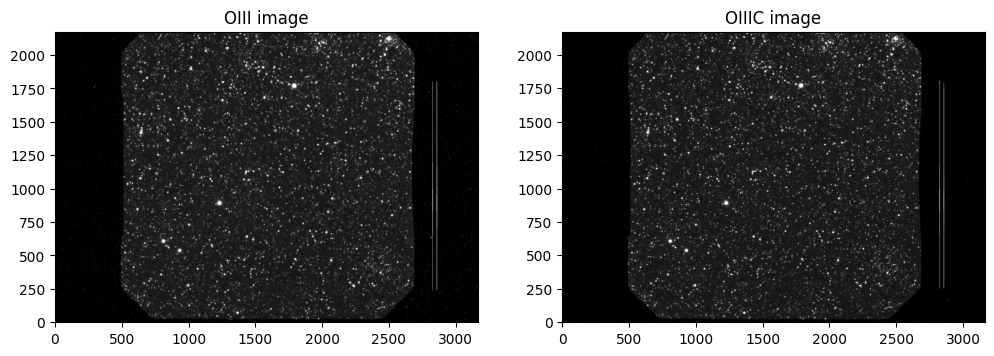

In [294]:
# plot image previews
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(oiii_image, origin="lower", cmap="gray", vmin=np.nanpercentile(oiii_image, 5), vmax=np.nanpercentile(oiii_image, 99.5))
ax1.set_title("OIII image")

ax2.imshow(oiiic_image, origin="lower", cmap="gray", vmin=np.nanpercentile(oiiic_image, 5), vmax=np.nanpercentile(oiiic_image, 99.5))
ax2.set_title("OIIIC image")

plt.show()

In [295]:
# identify sources in the images

# OIII stats
mean, median, std = sigma_clipped_stats(oiii_image)

# create a list of detected sources
daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundness_range=(-0.2, 0.2))
sources = daofind(oiii_image - median)

# get 50 stars with the most flux
sources.sort("flux")
sources.reverse()
brightest = sources[:150]

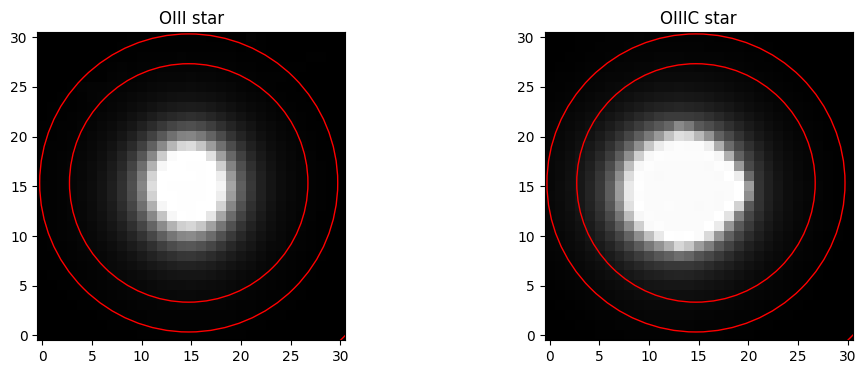

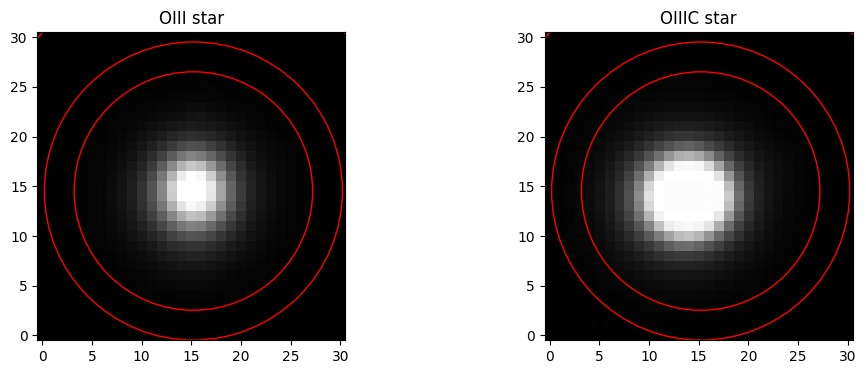

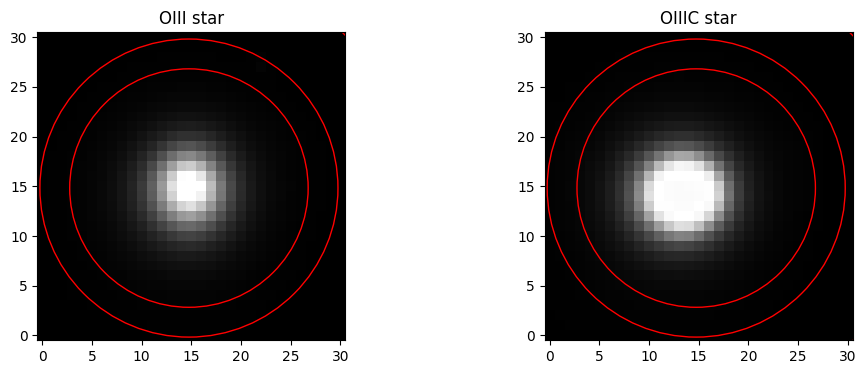

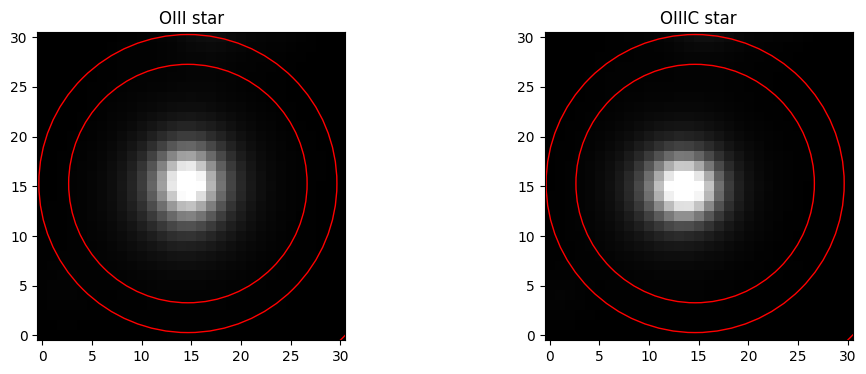

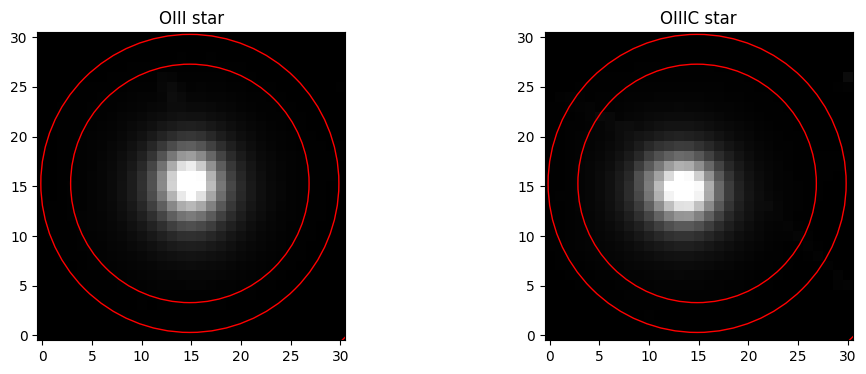

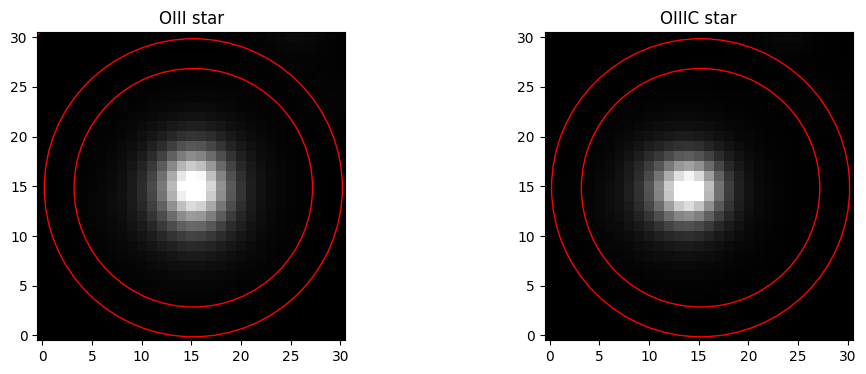

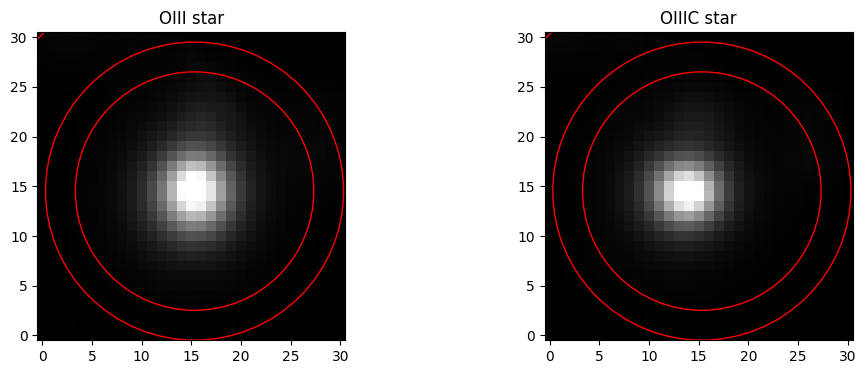

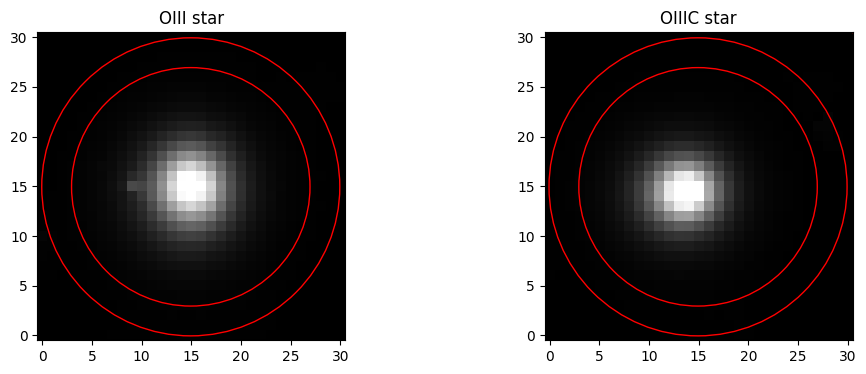

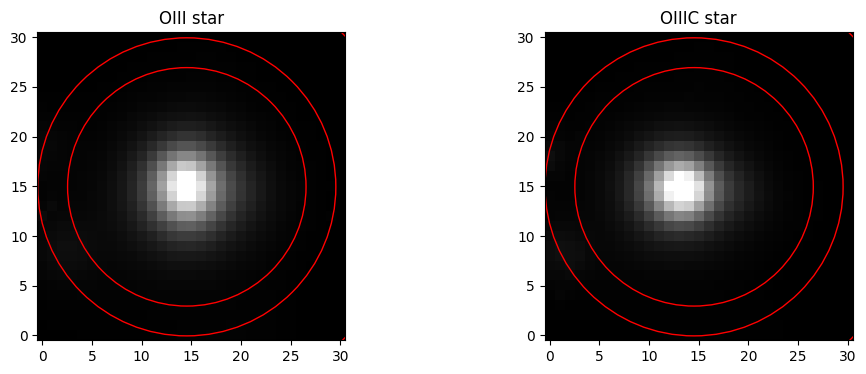

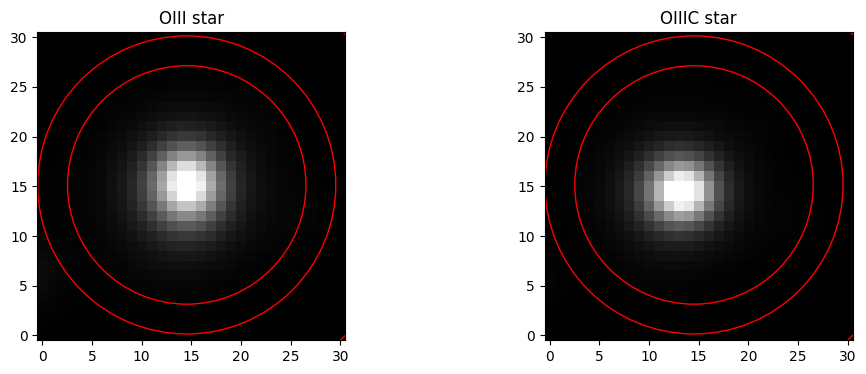

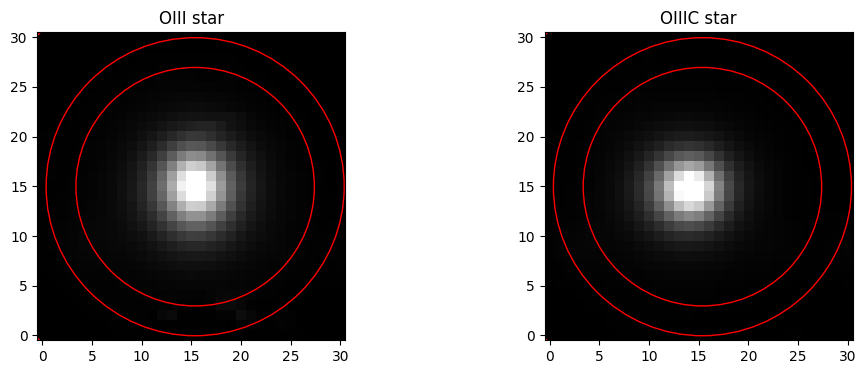

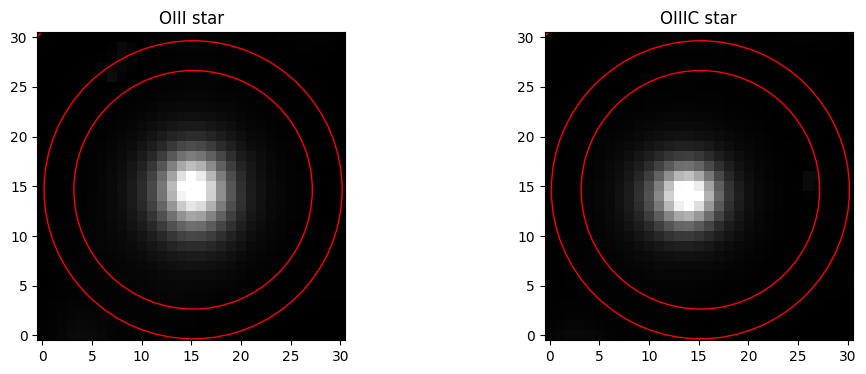

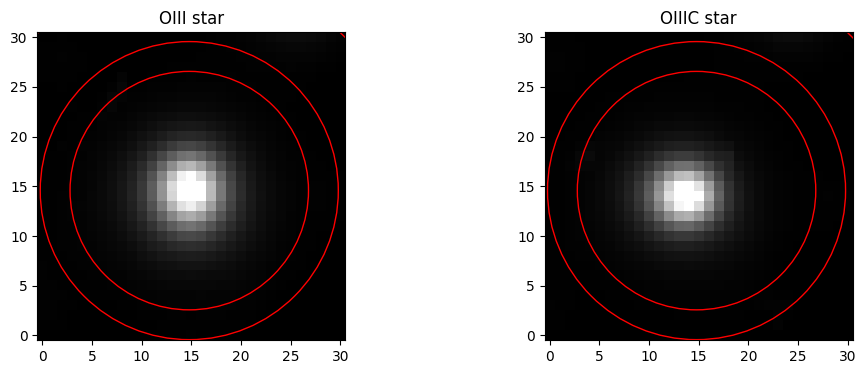

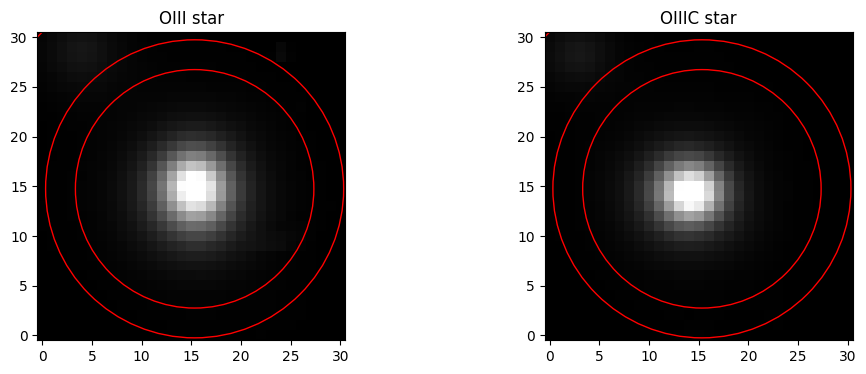

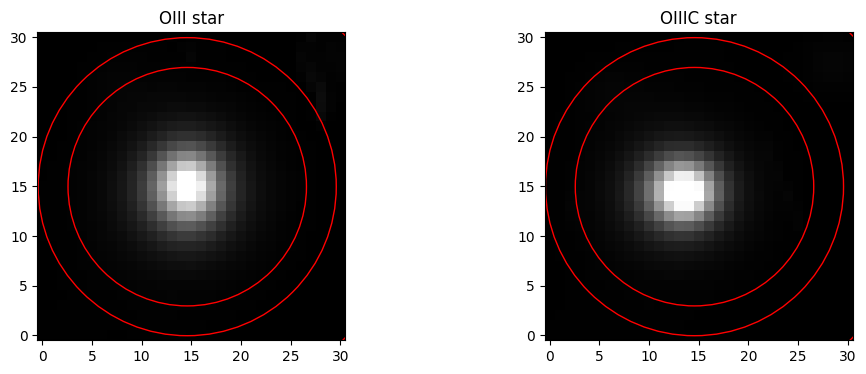

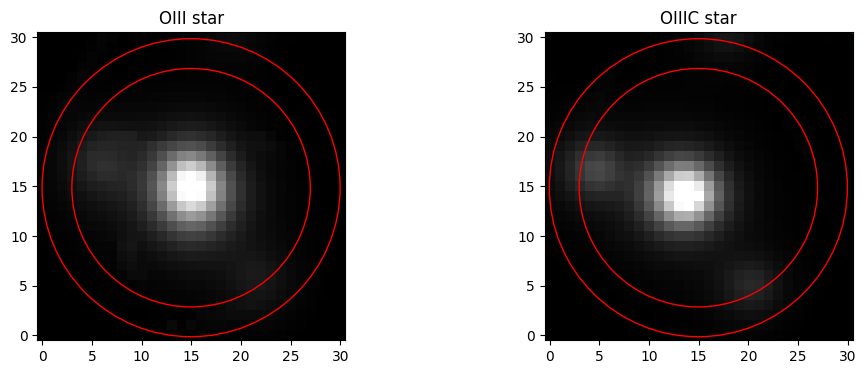

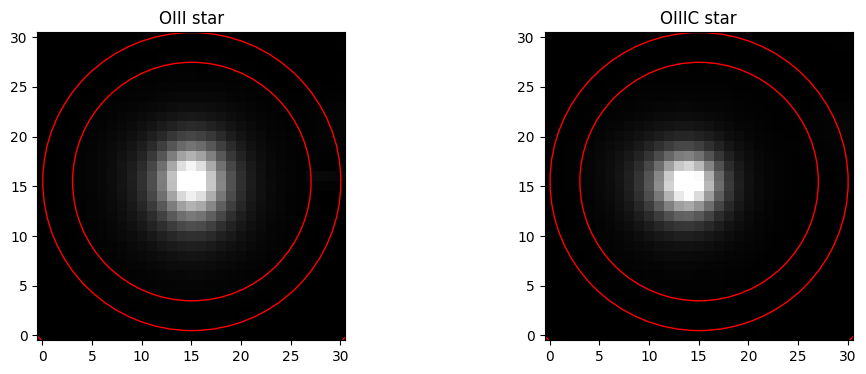

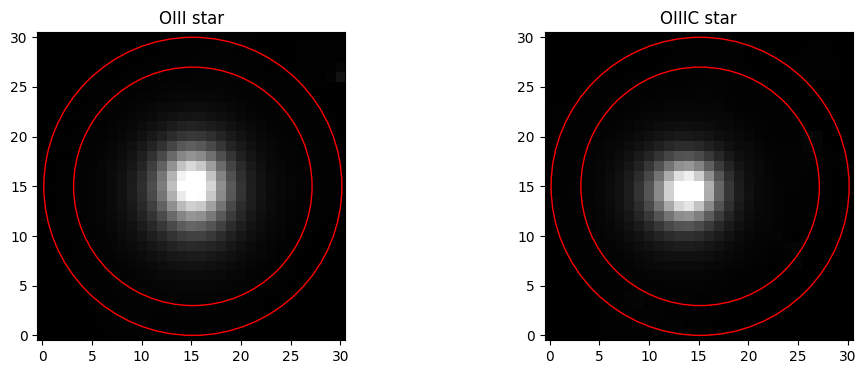

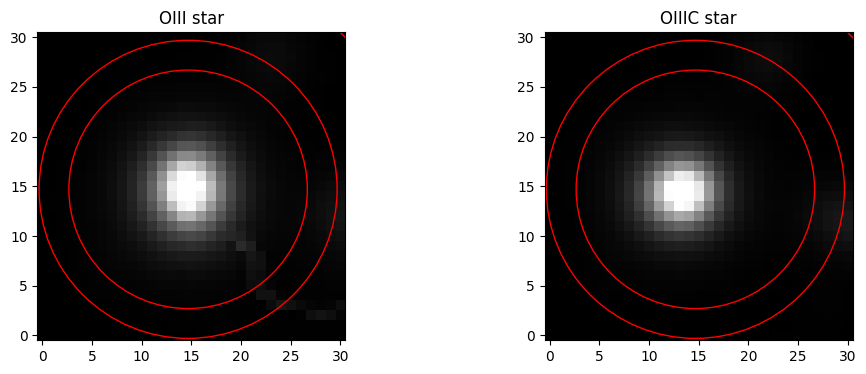

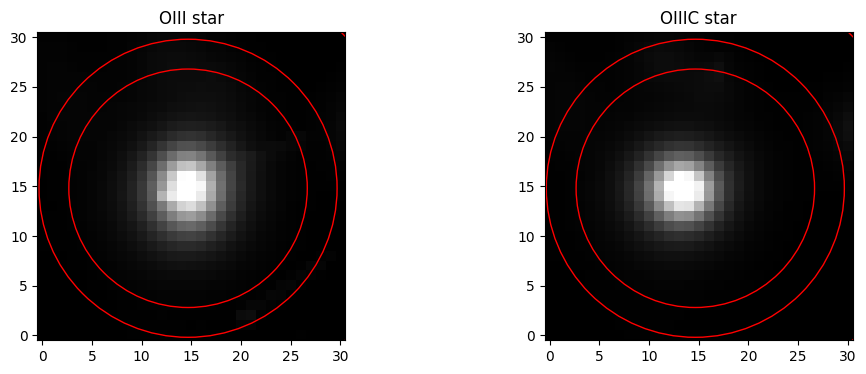

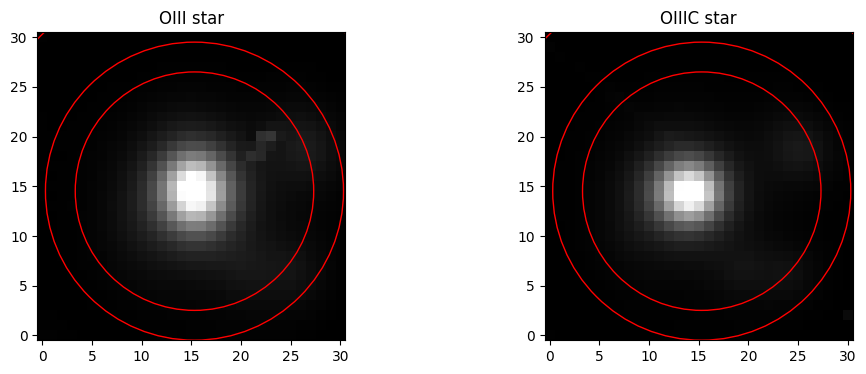

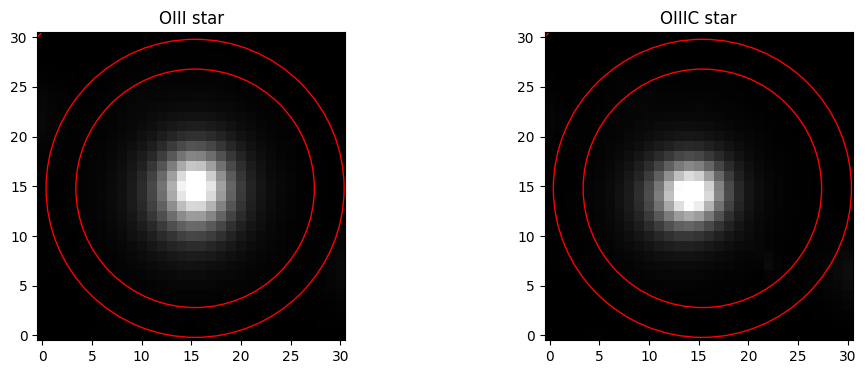

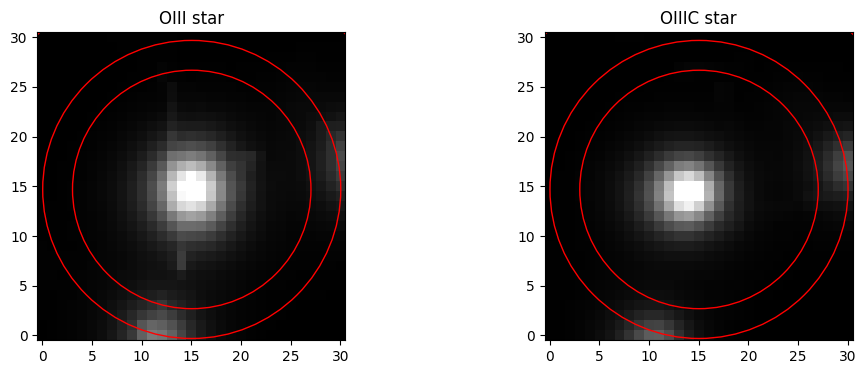

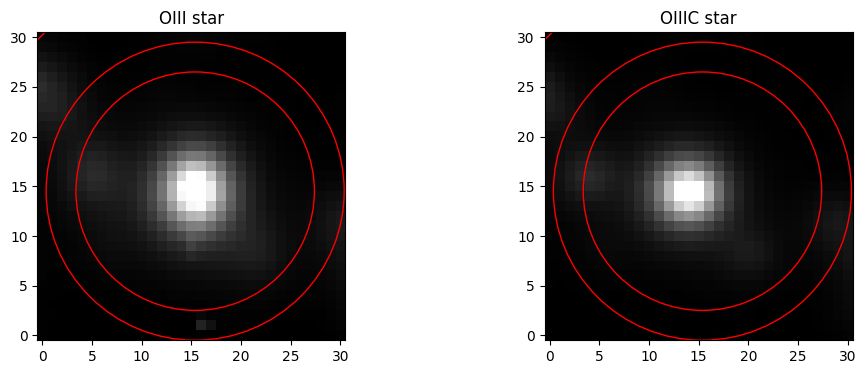

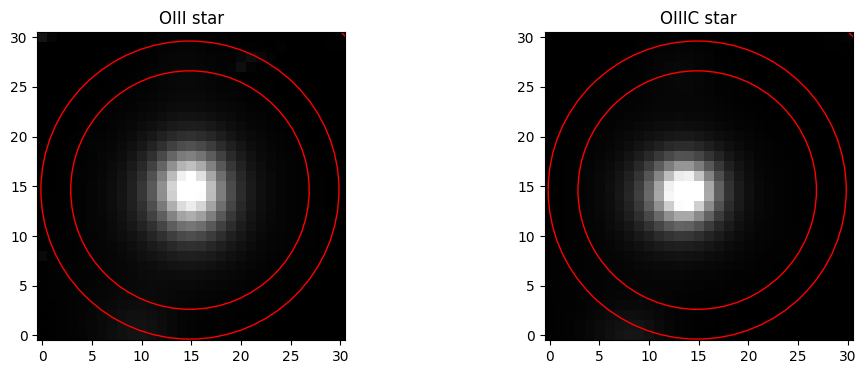

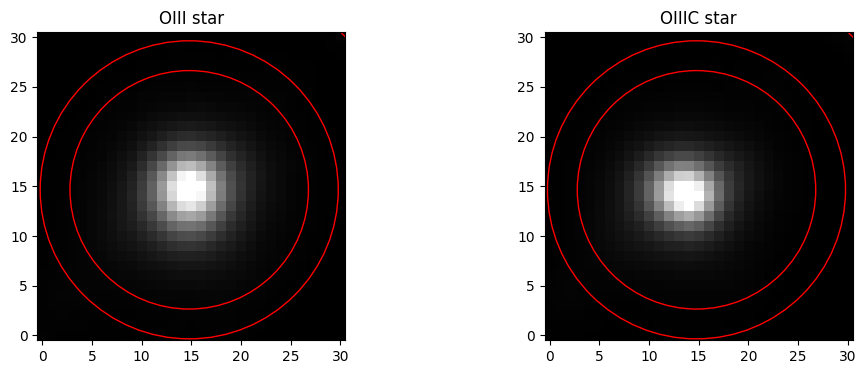

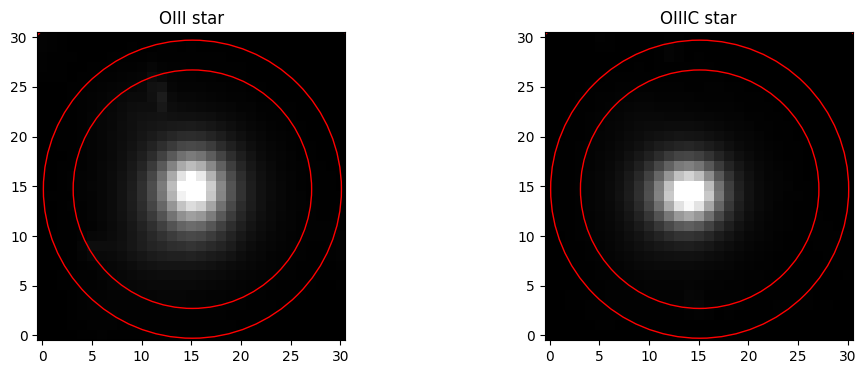

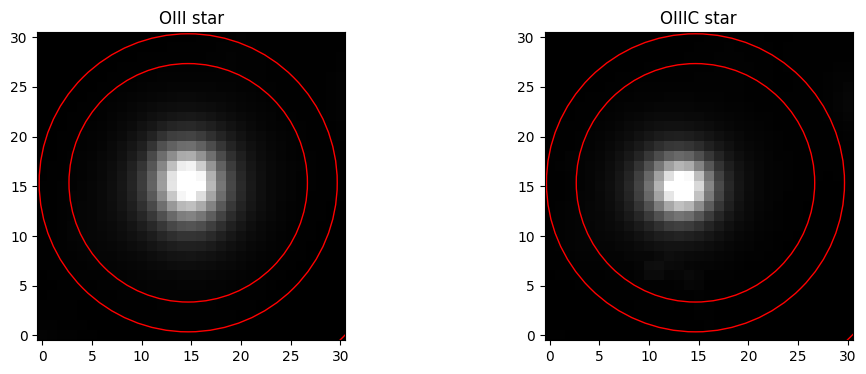

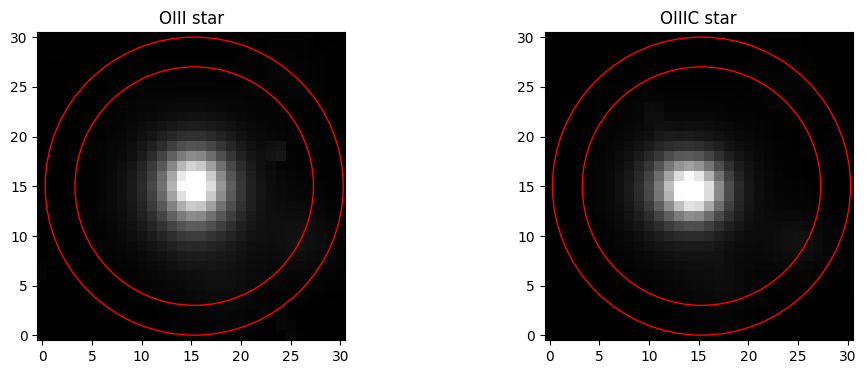

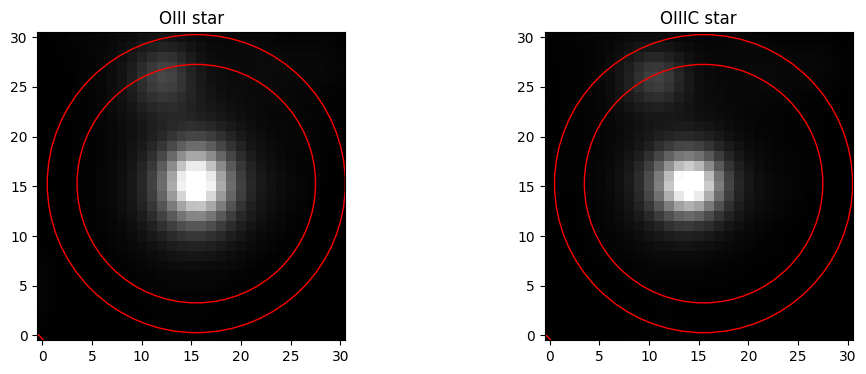

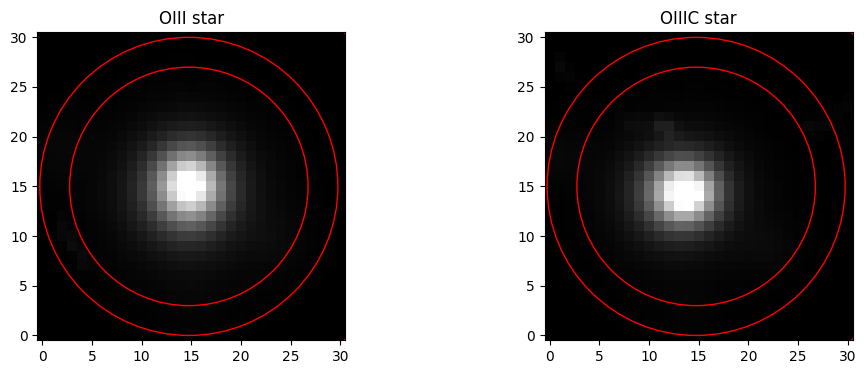

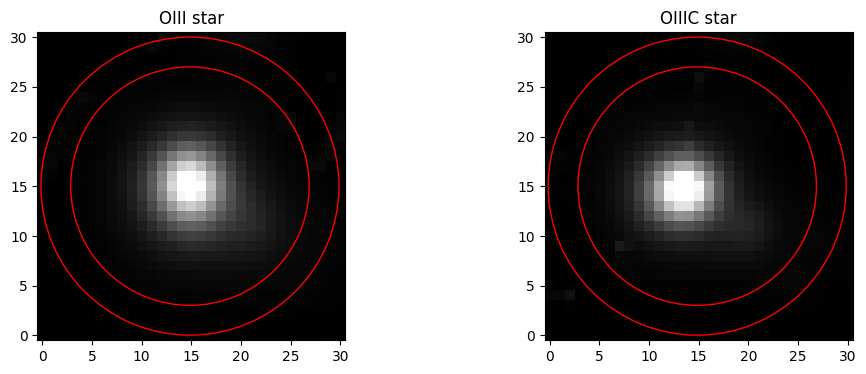

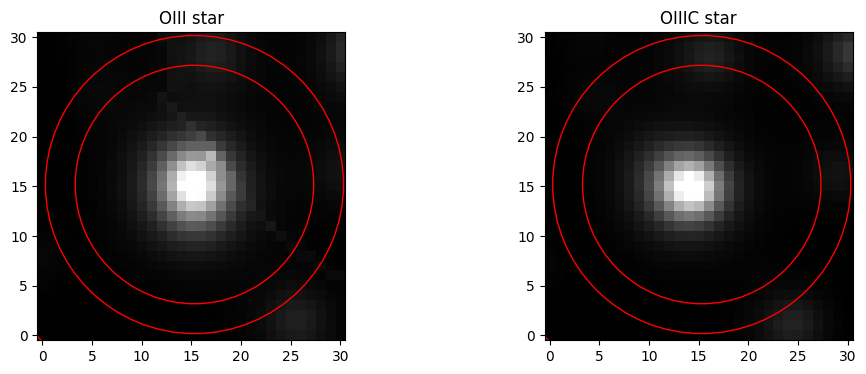

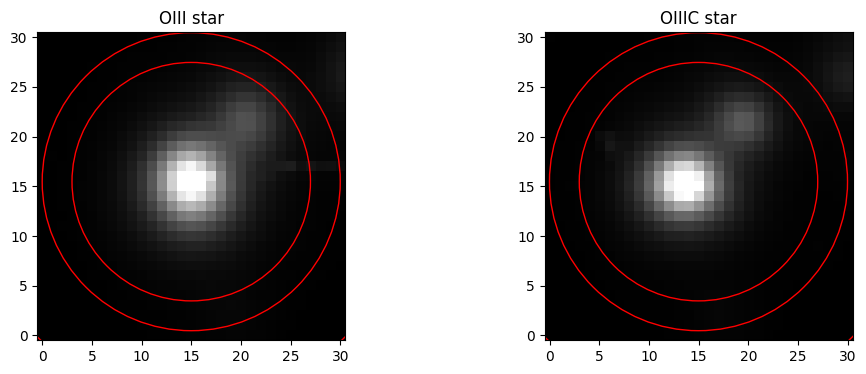

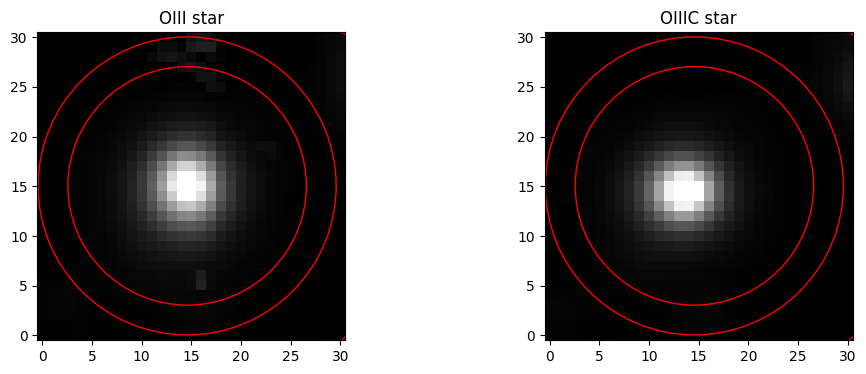

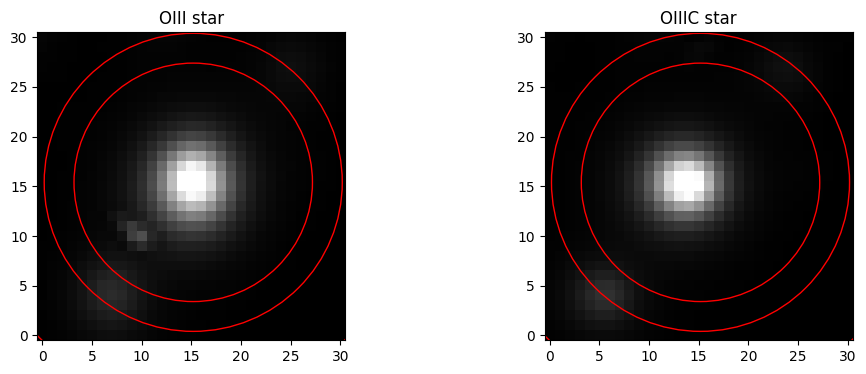

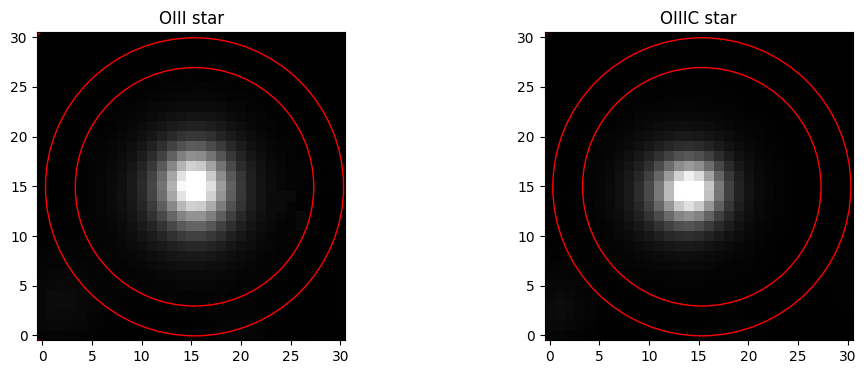

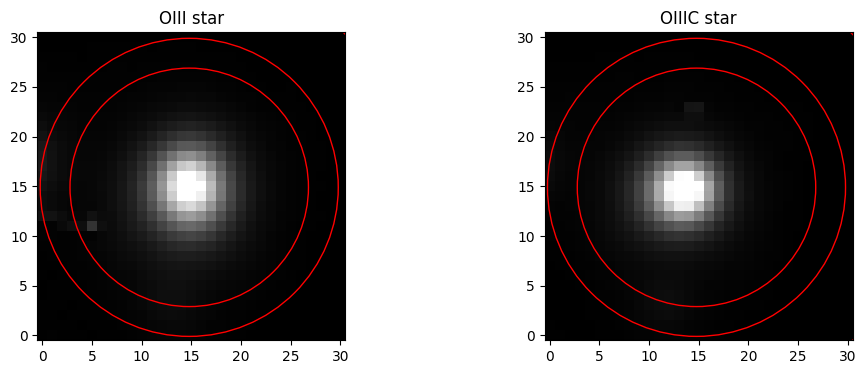

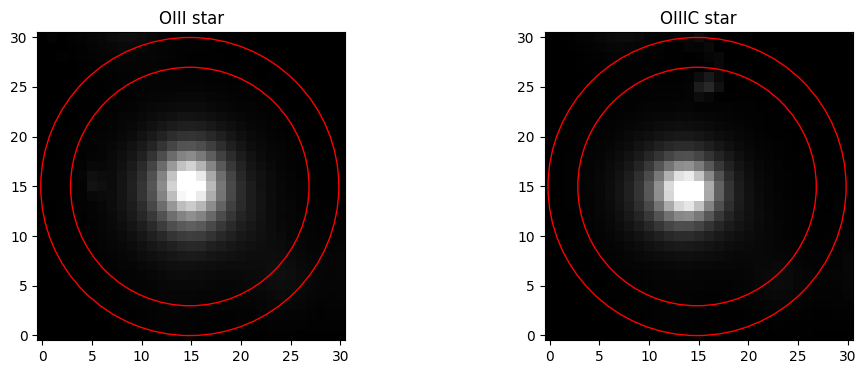

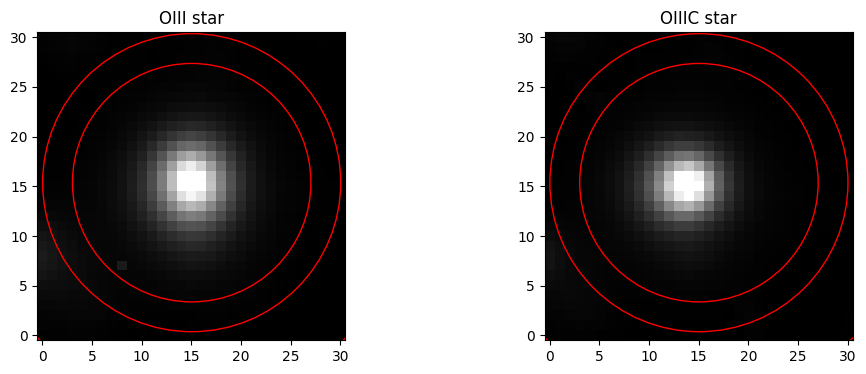

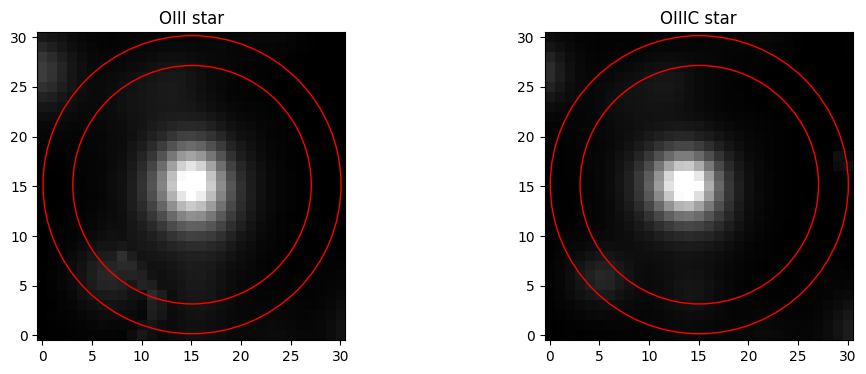

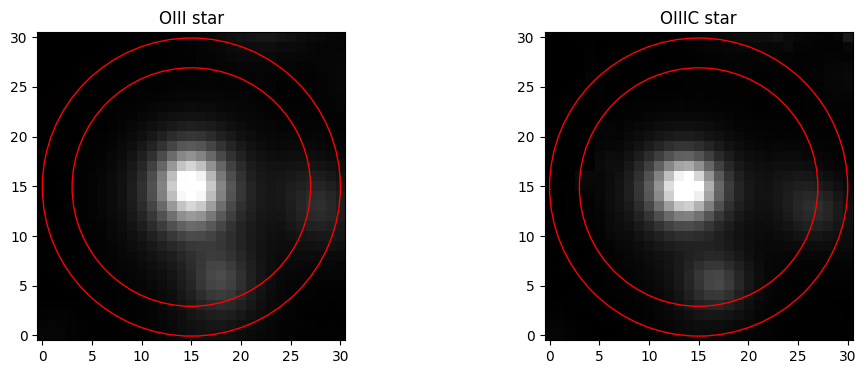

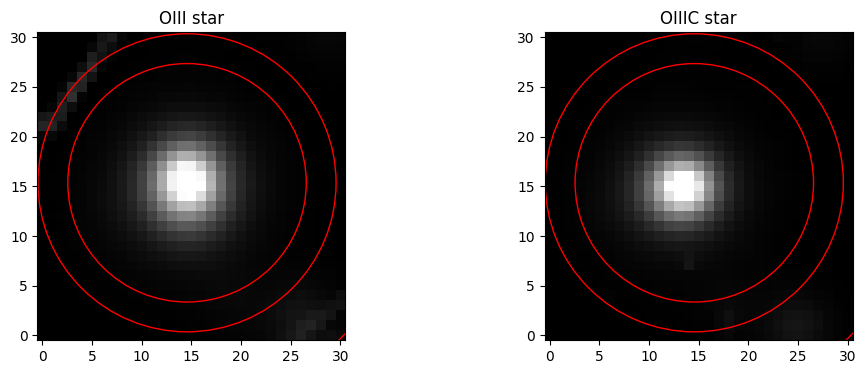

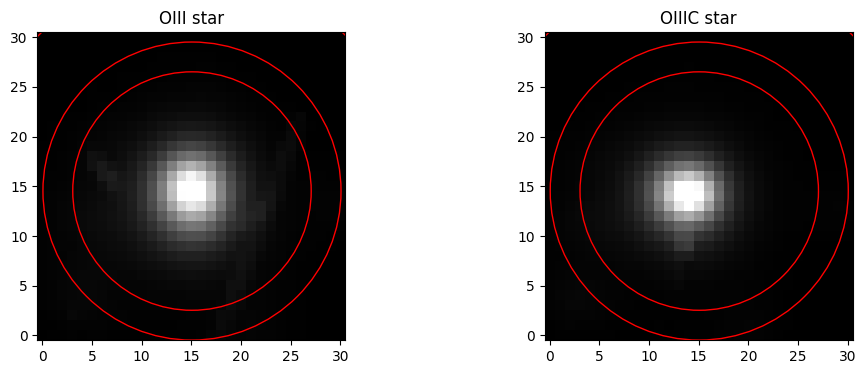

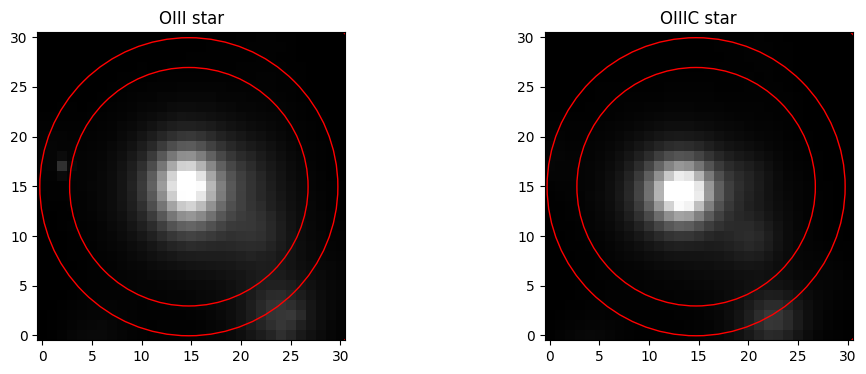

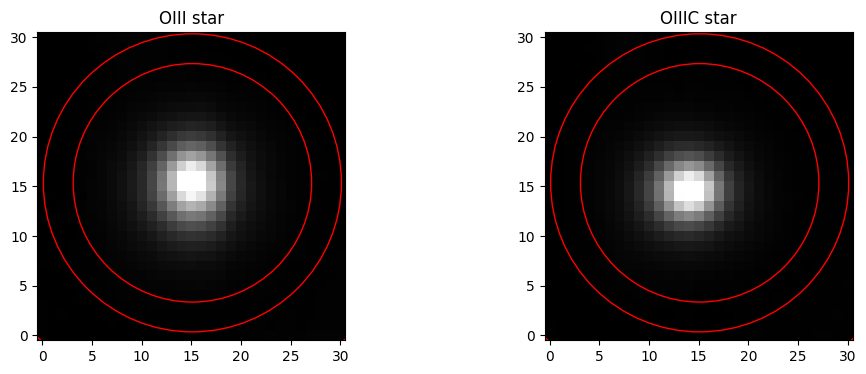

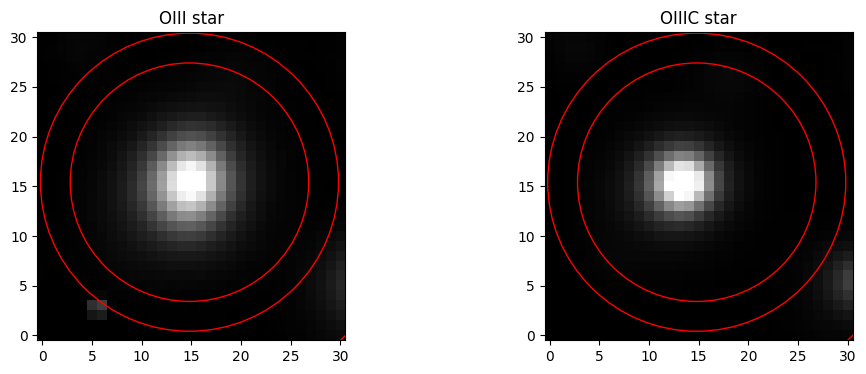

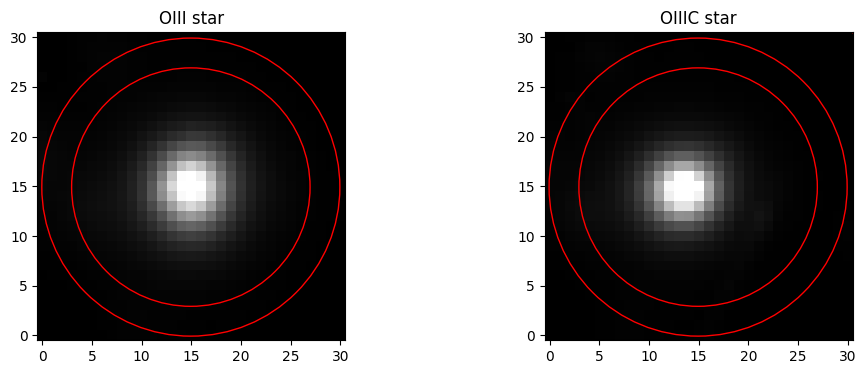

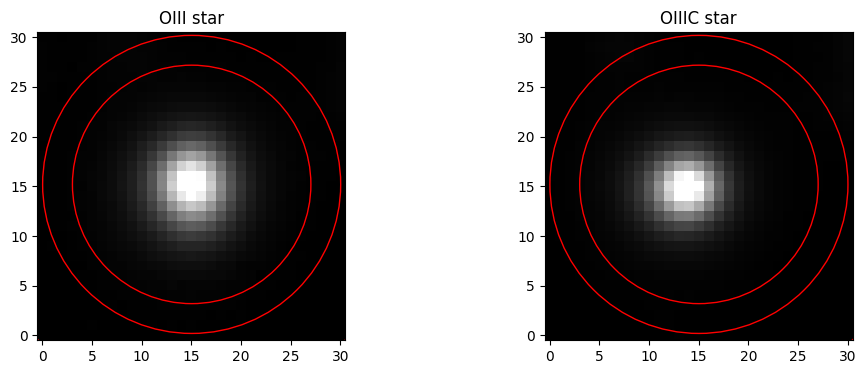

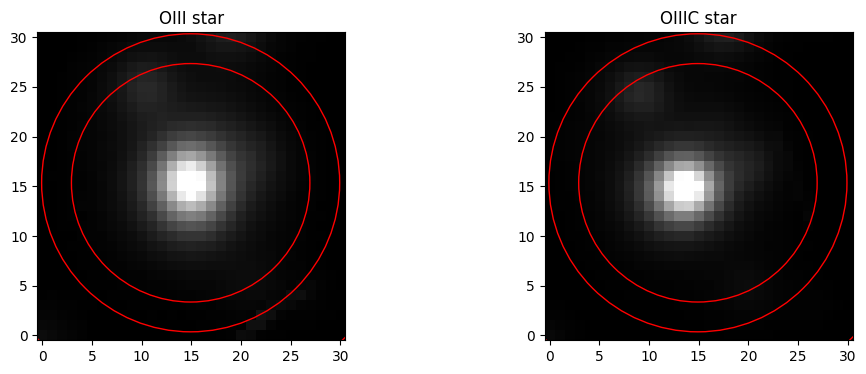

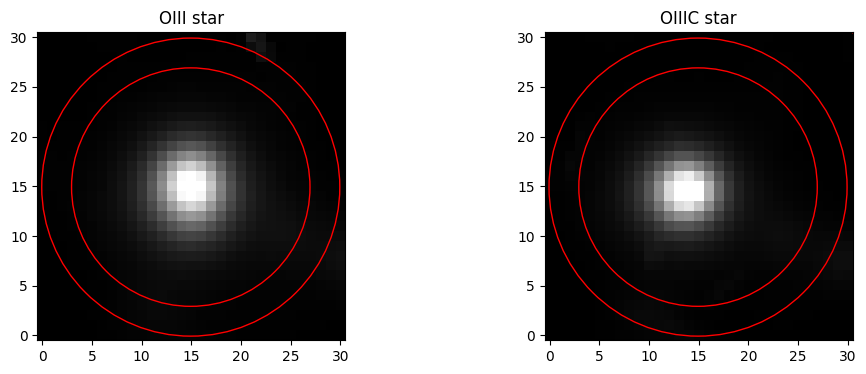

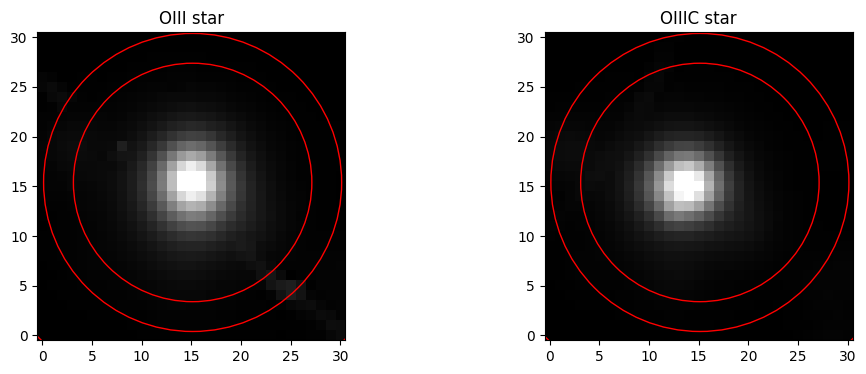

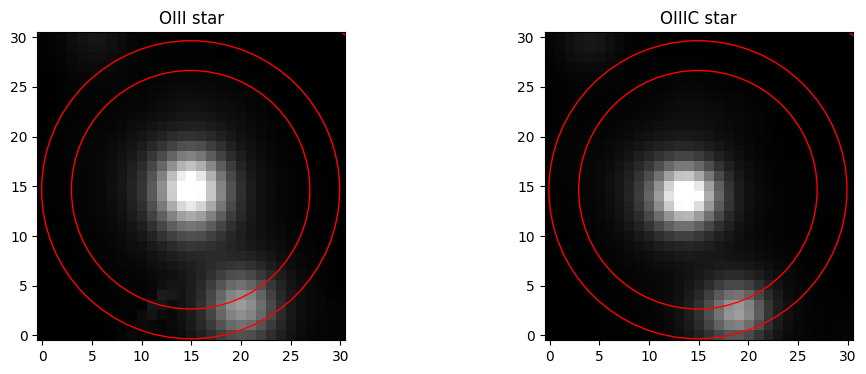

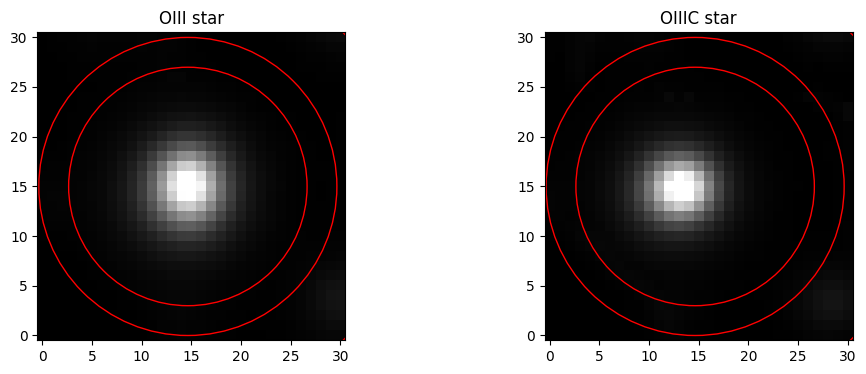

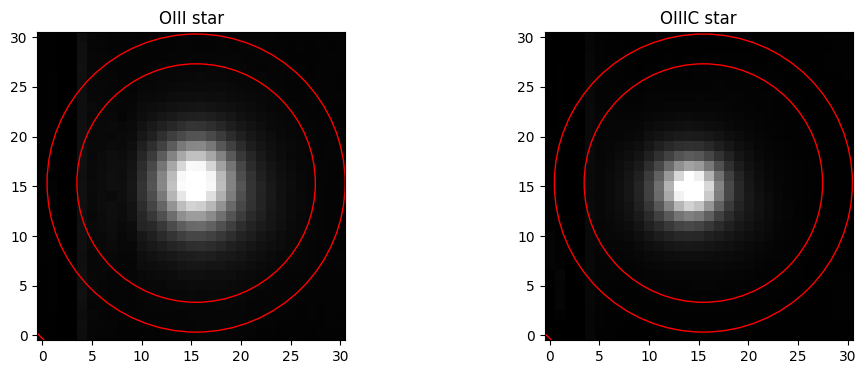

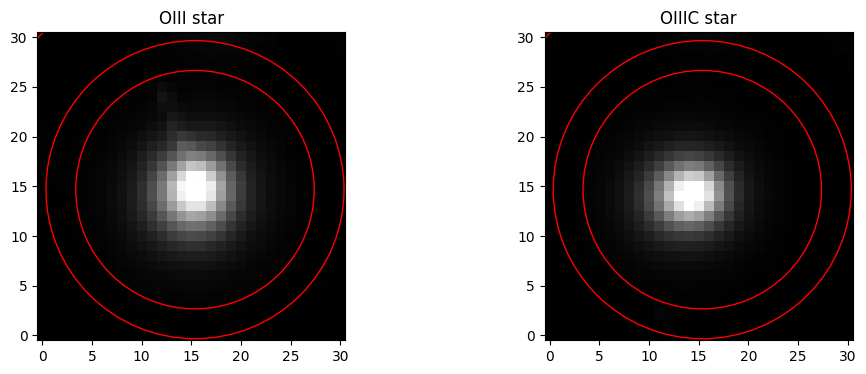

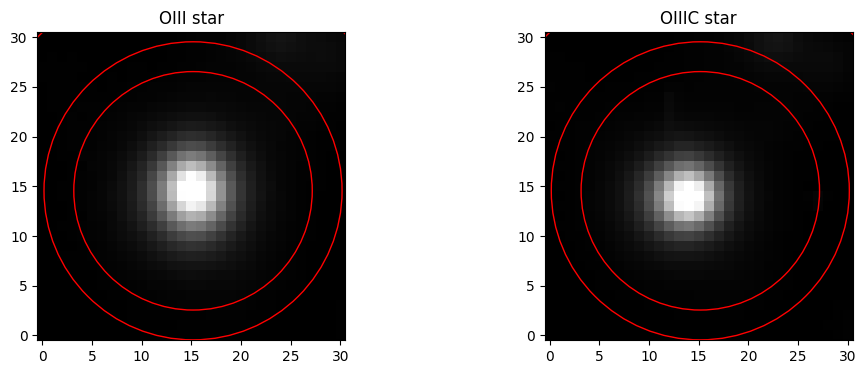

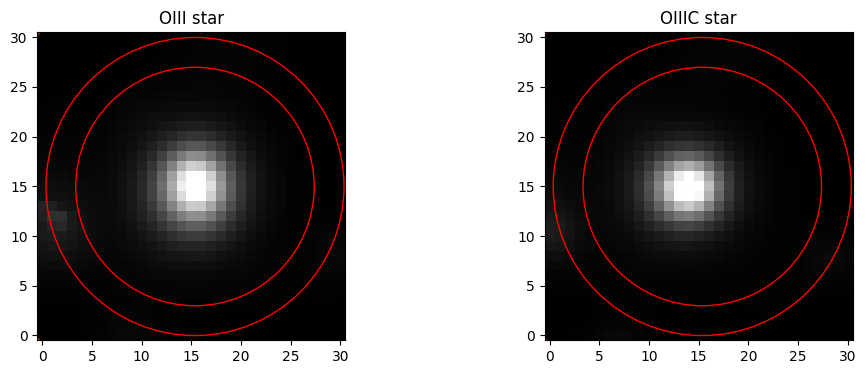

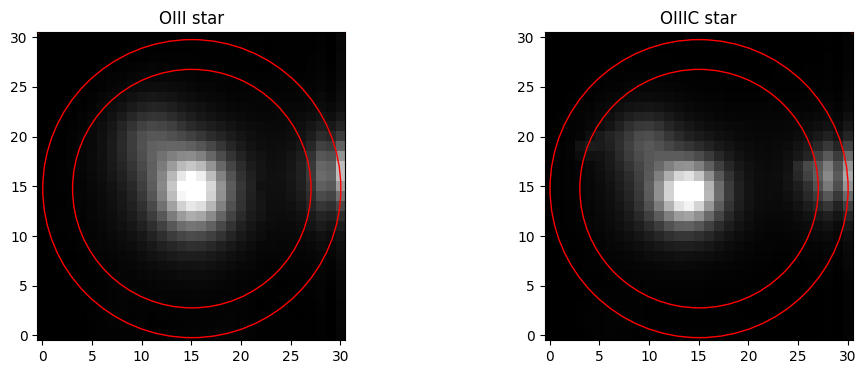

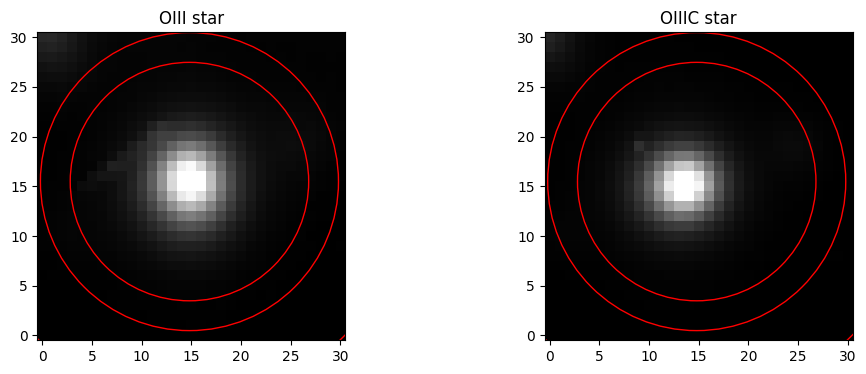

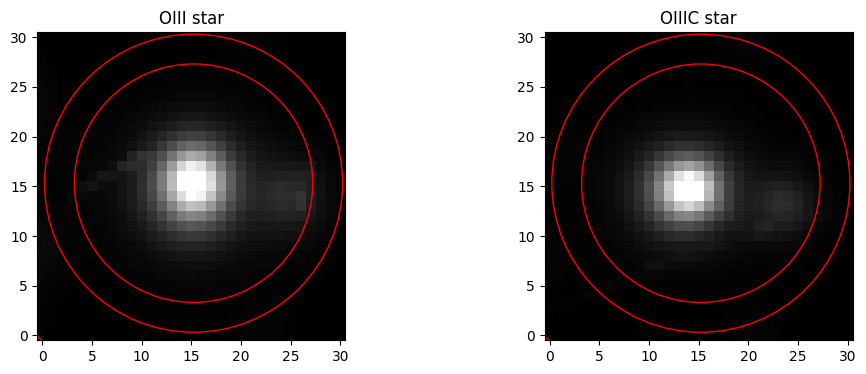

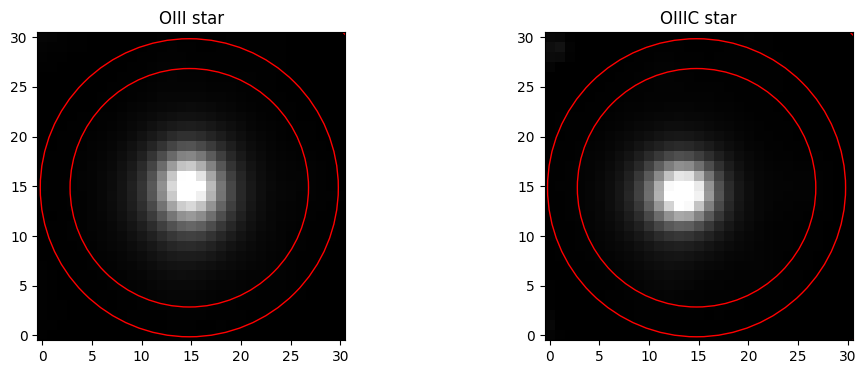

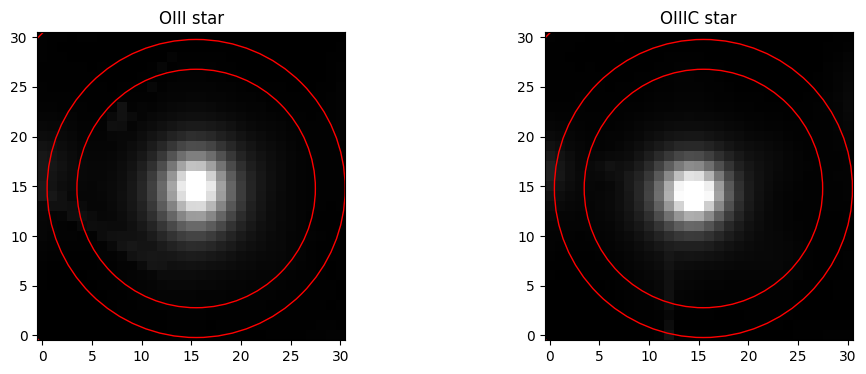

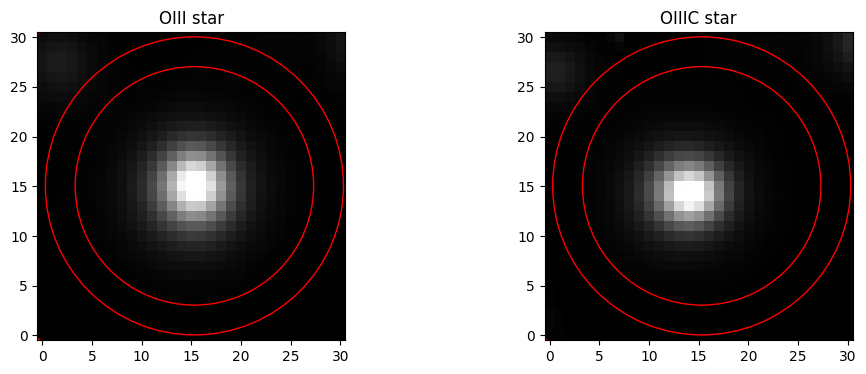

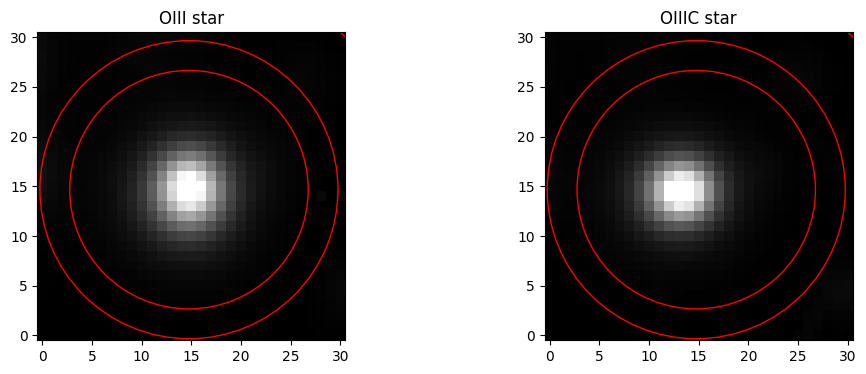

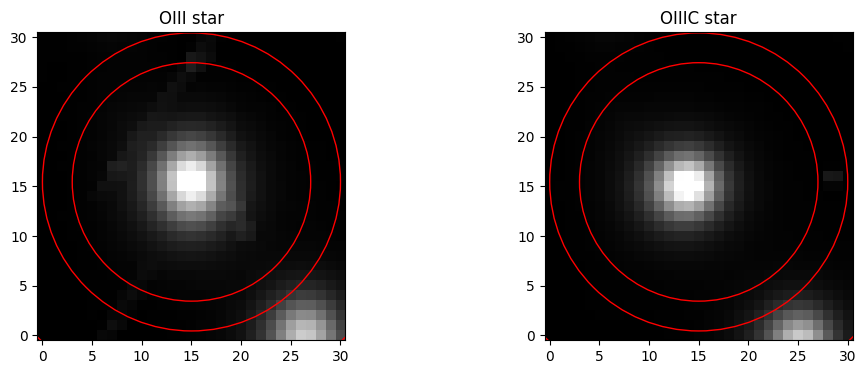

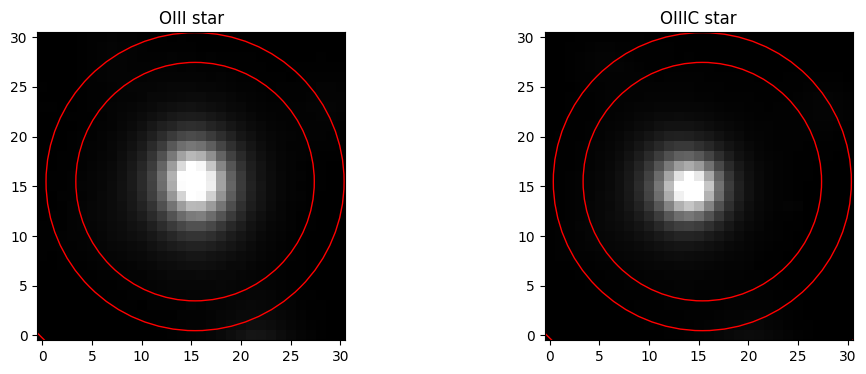

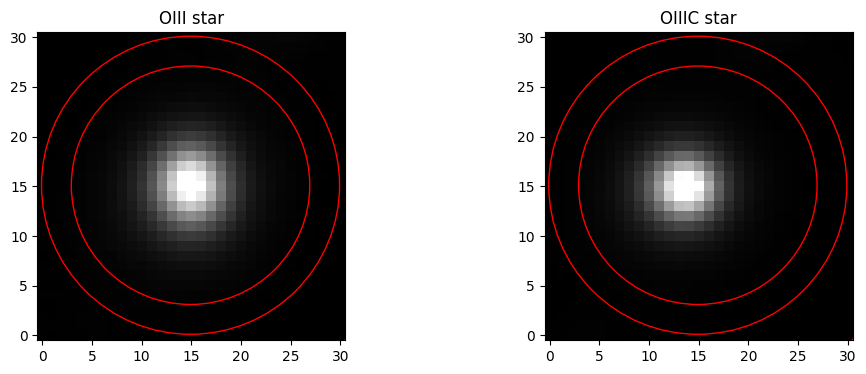

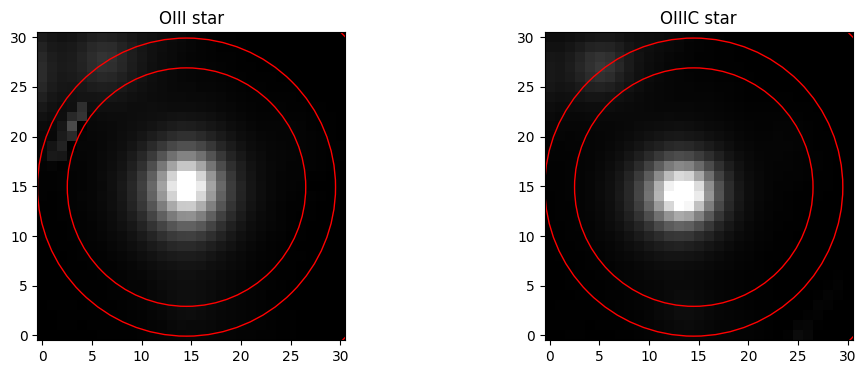

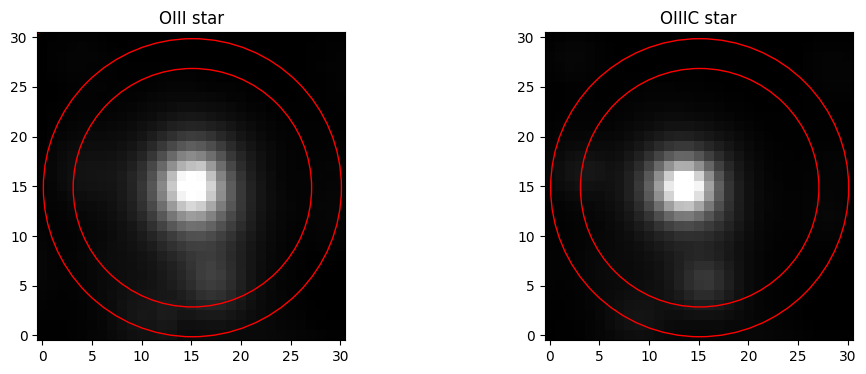

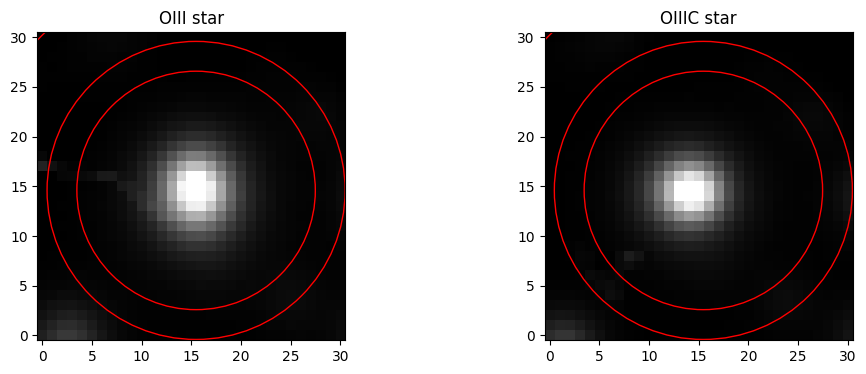

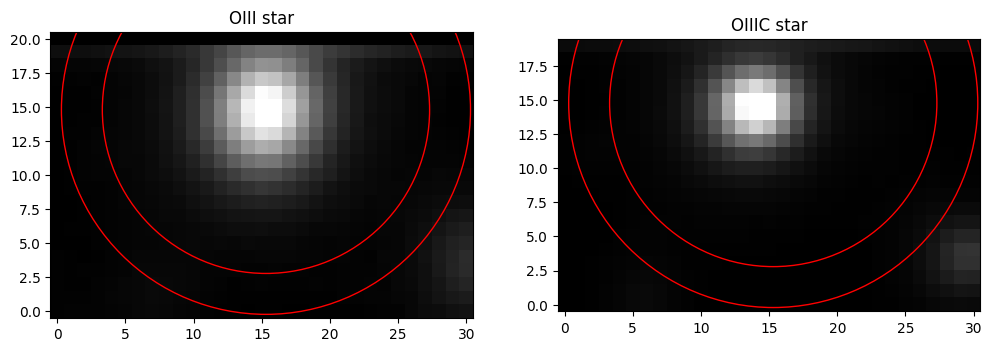

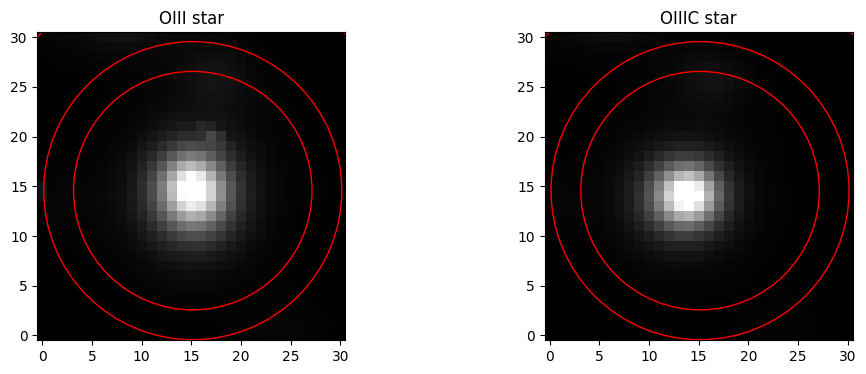

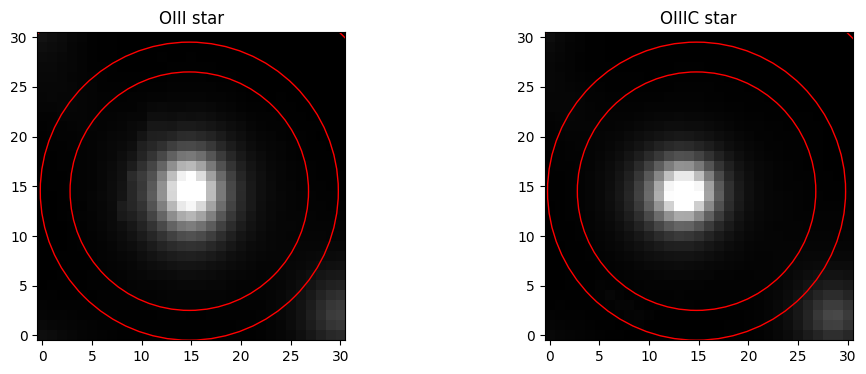

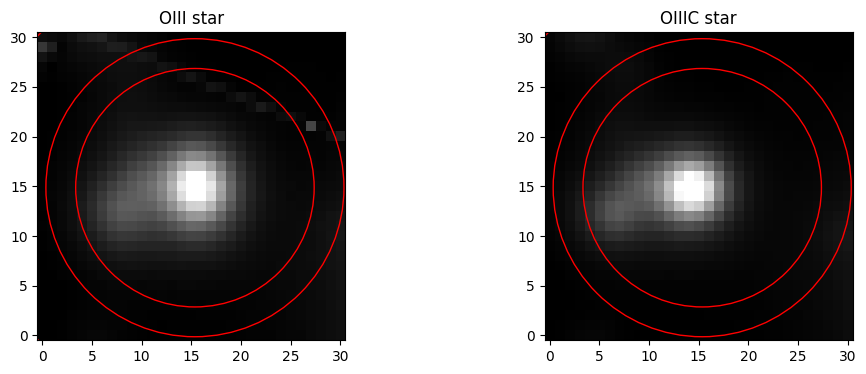

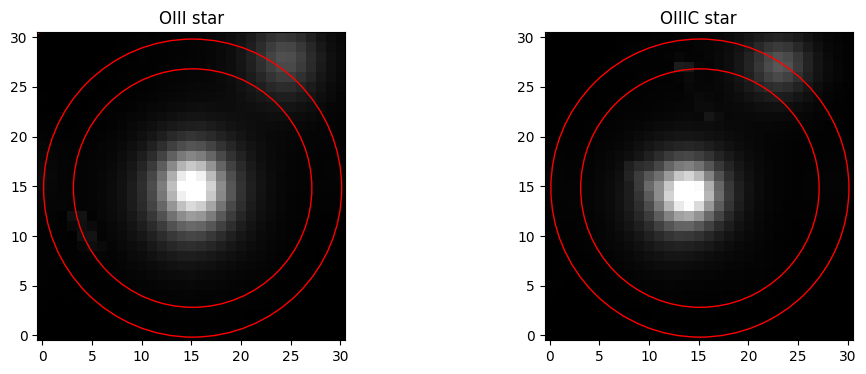

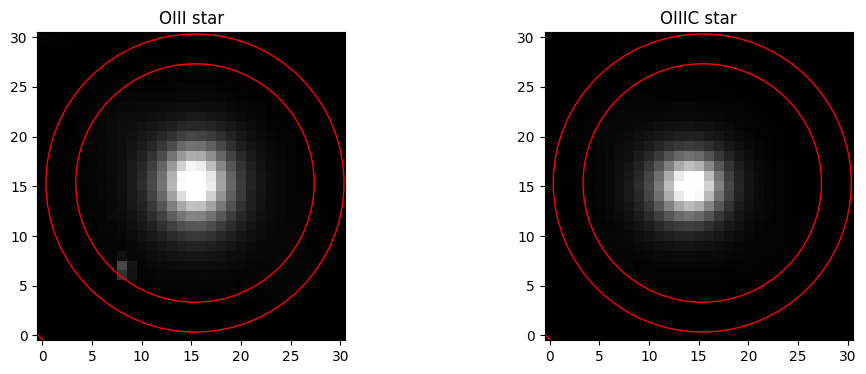

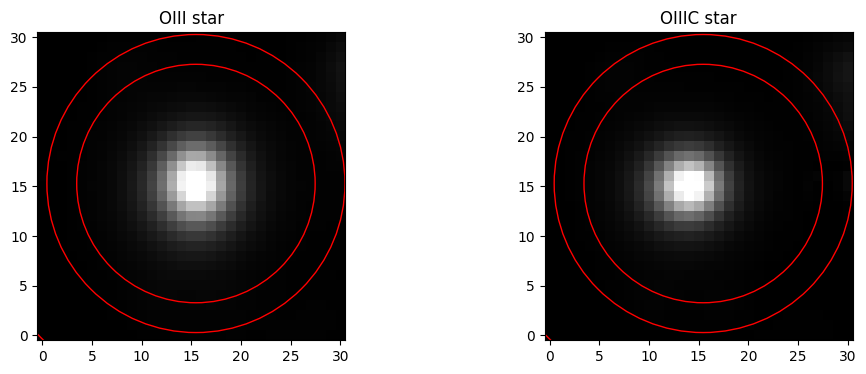

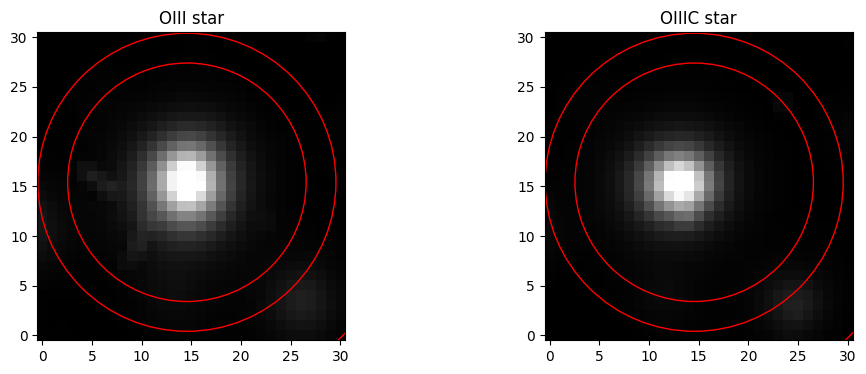

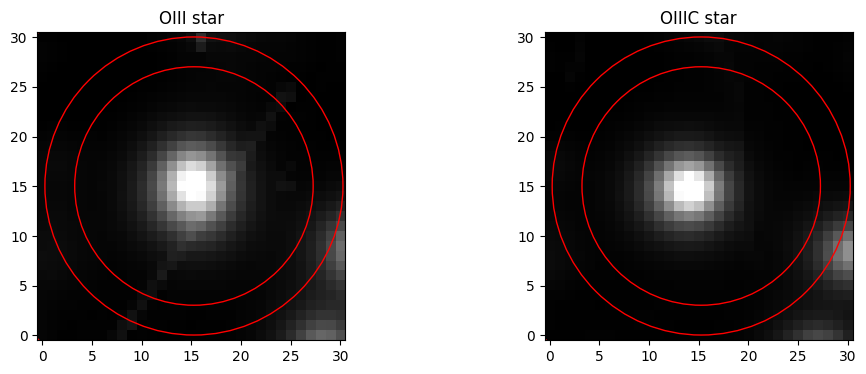

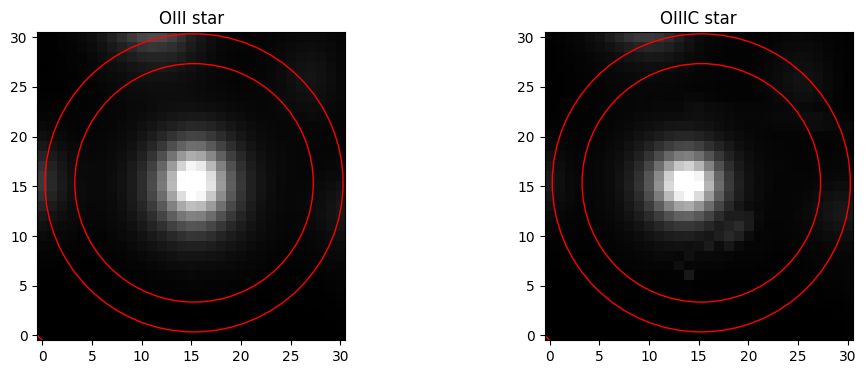

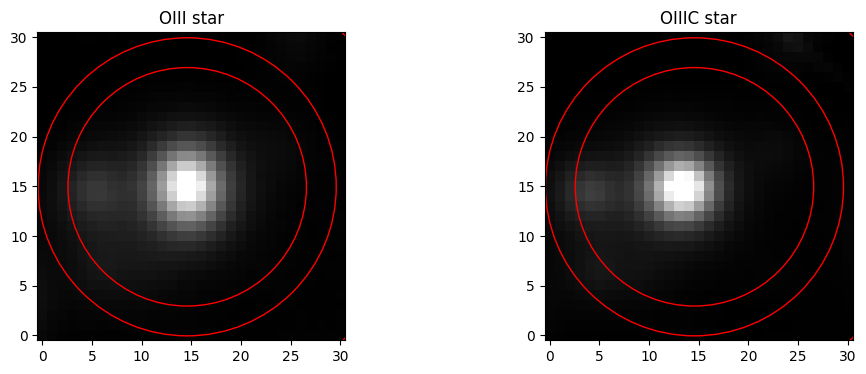

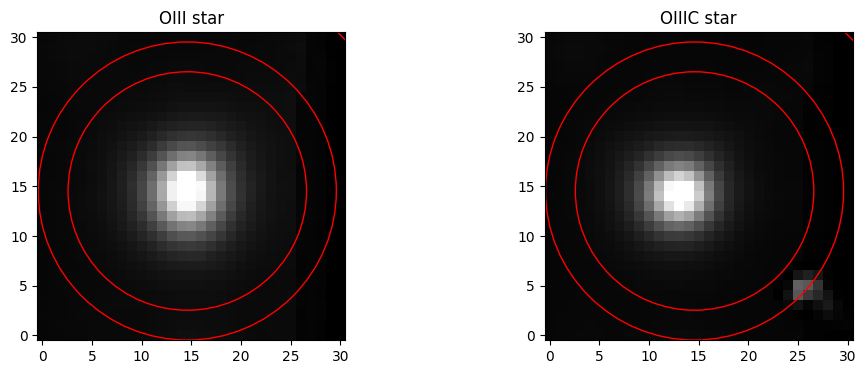

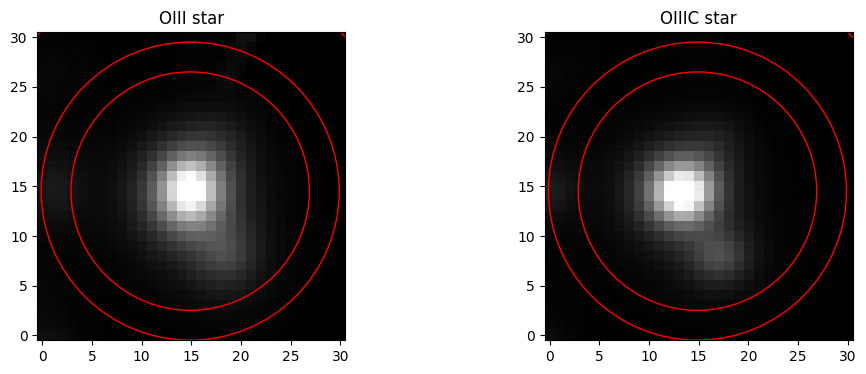

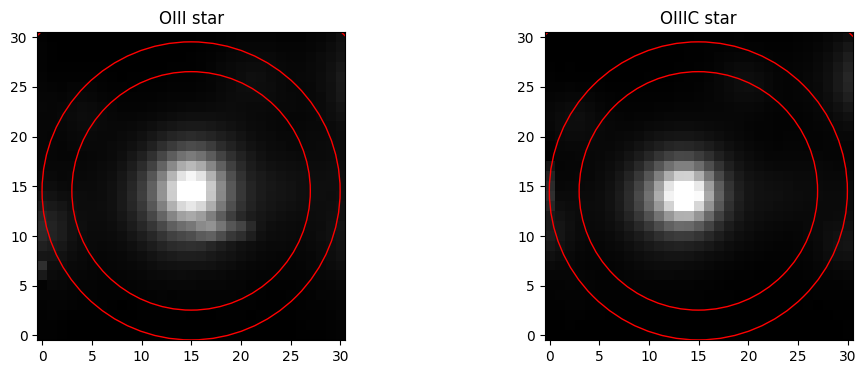

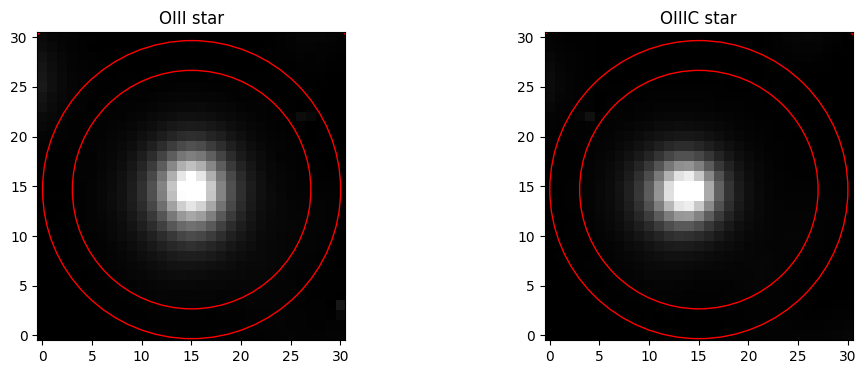

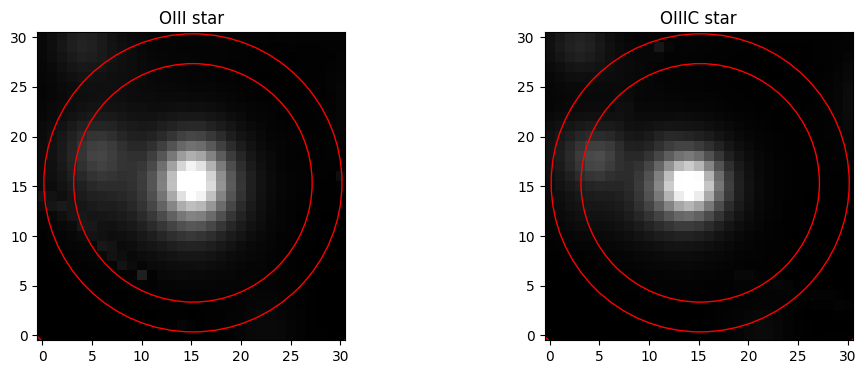

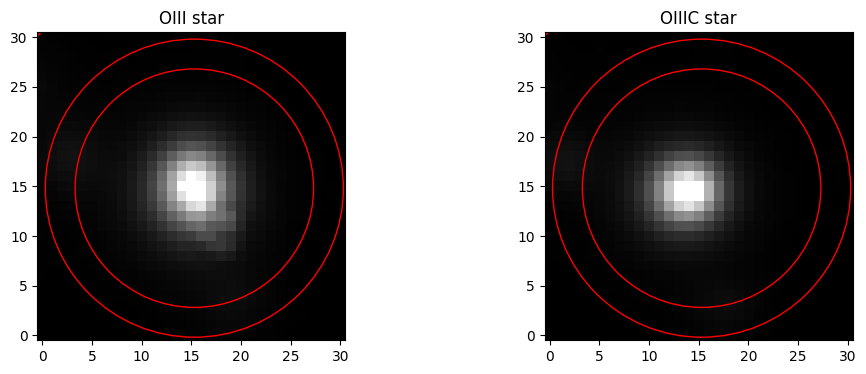

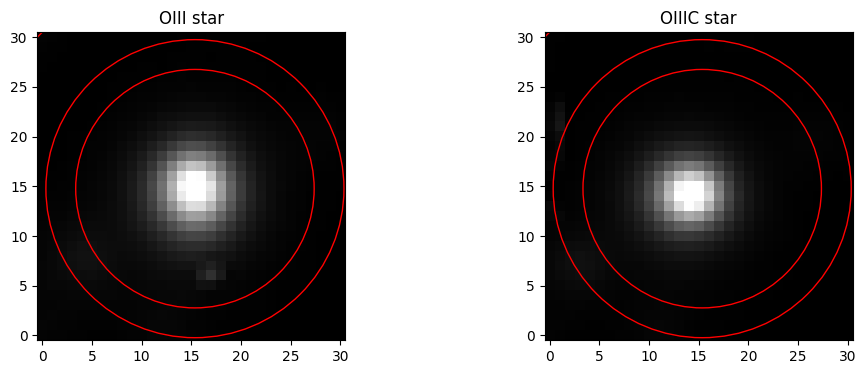

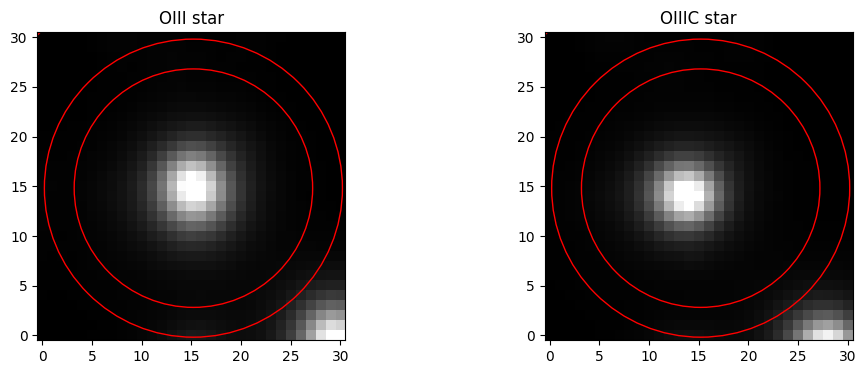

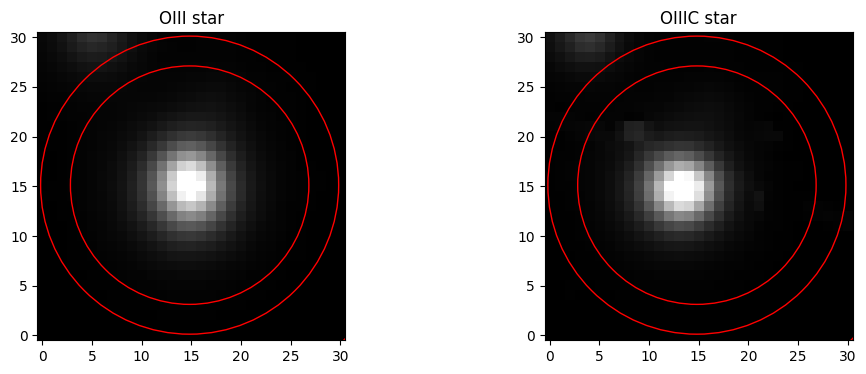

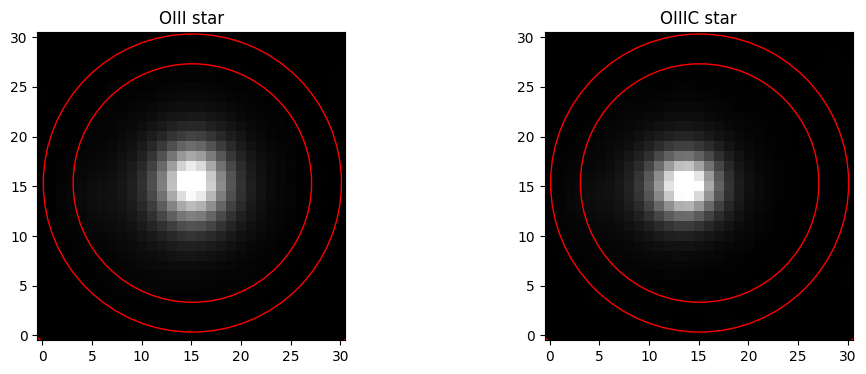

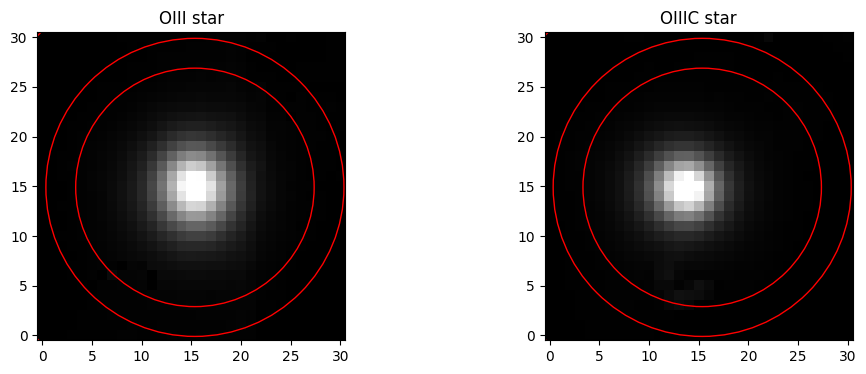

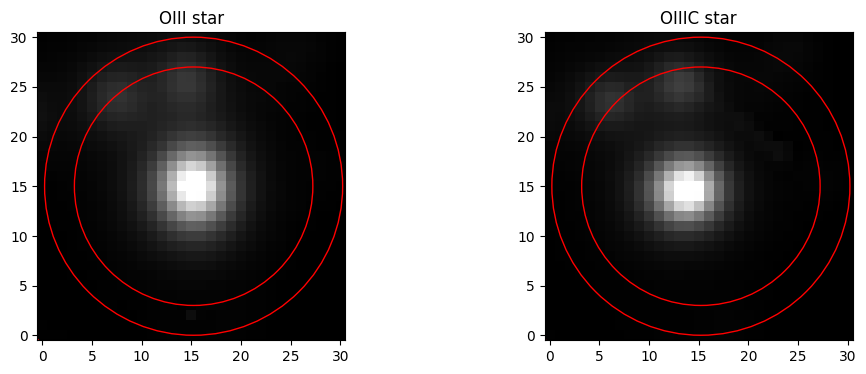

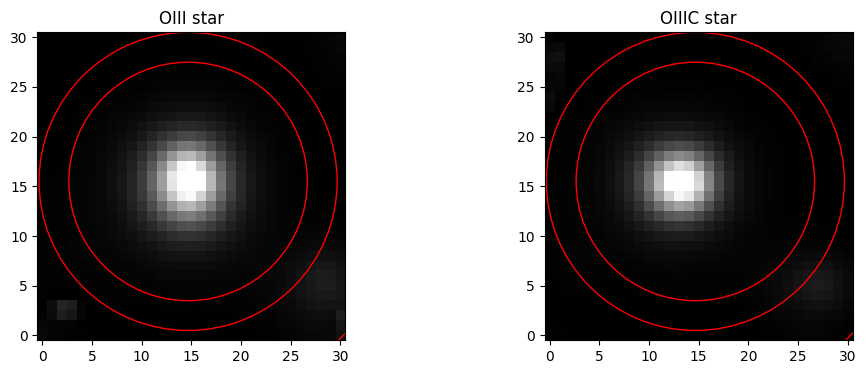

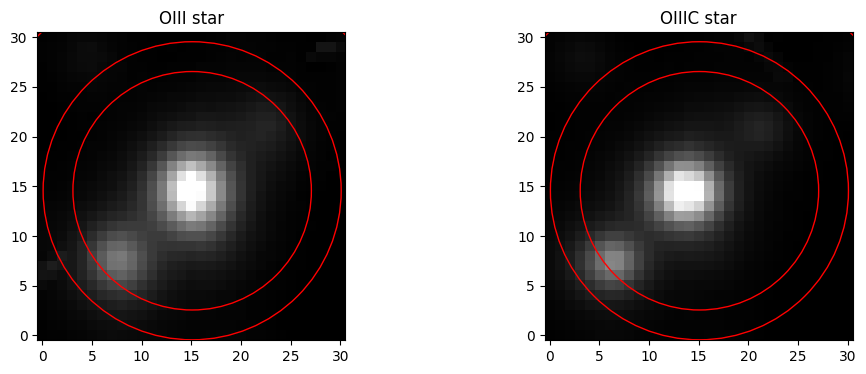

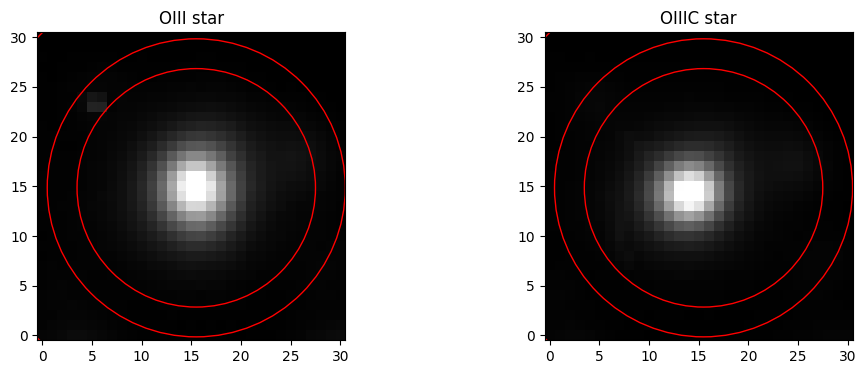

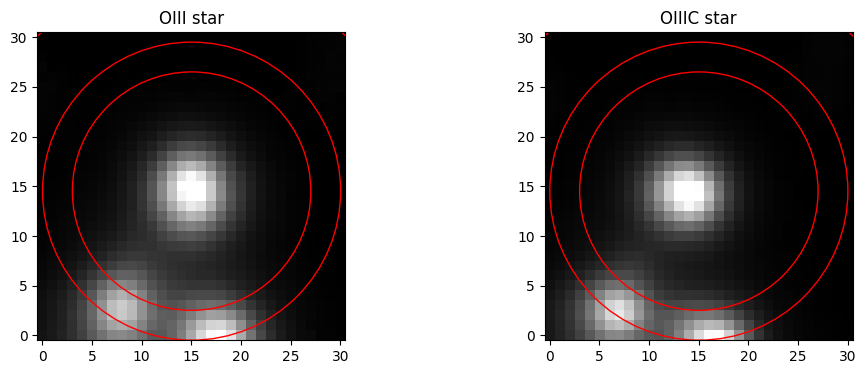

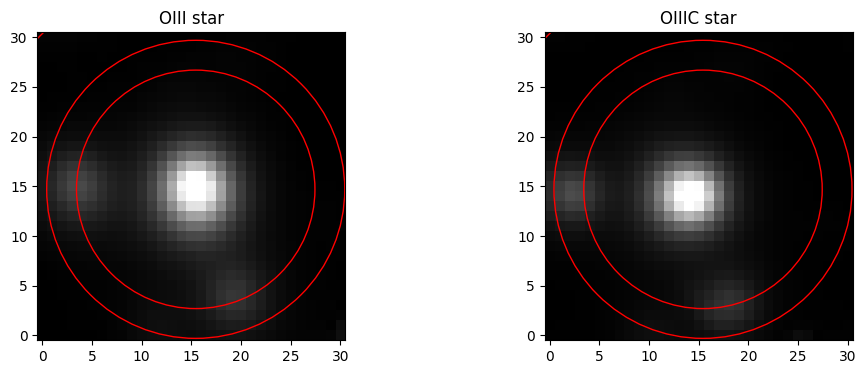

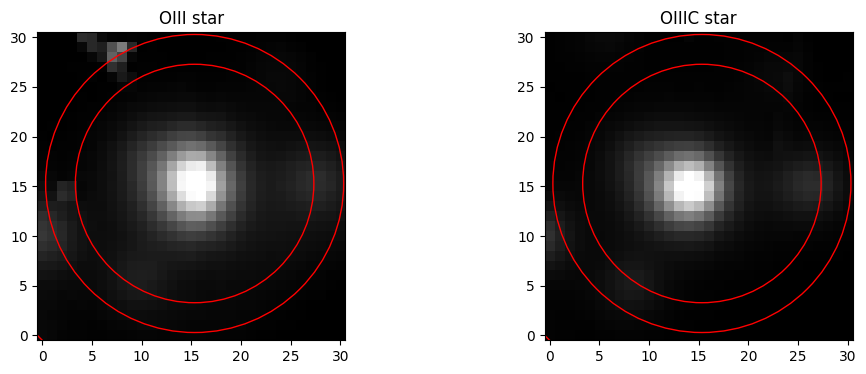

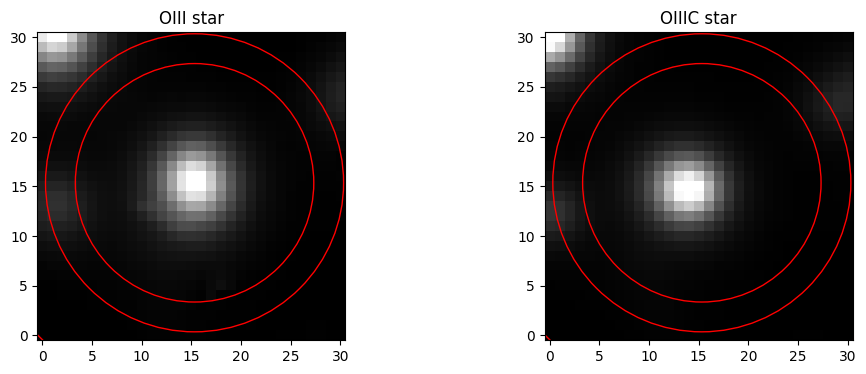

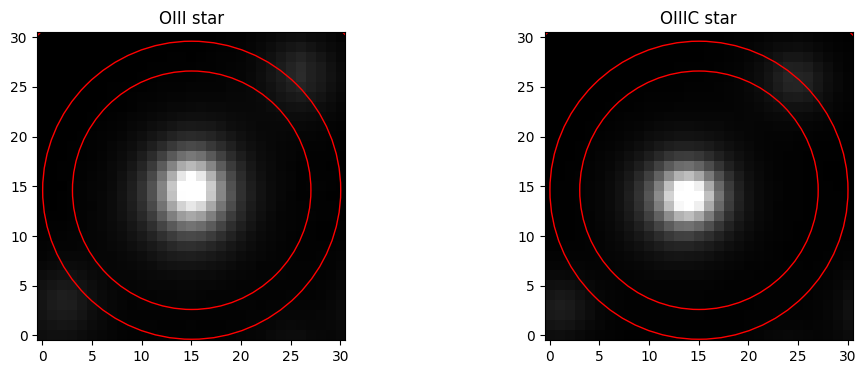

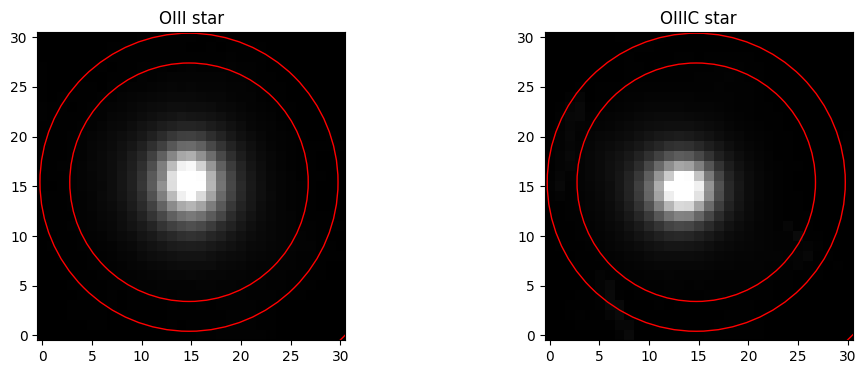

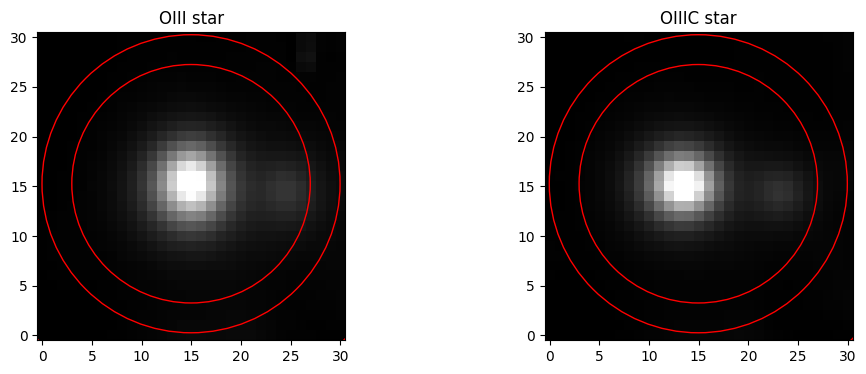

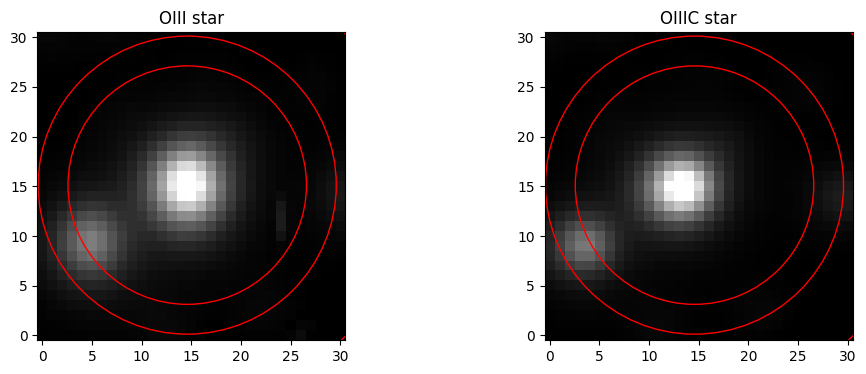

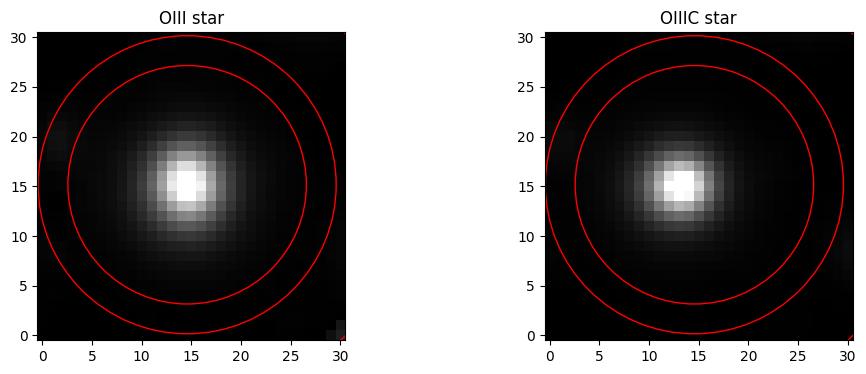

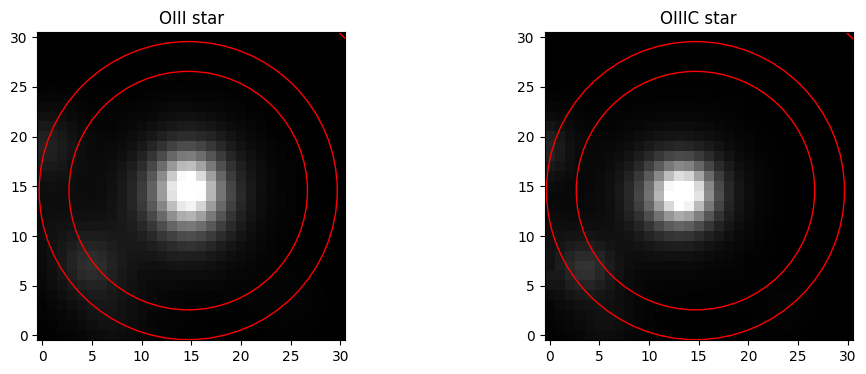

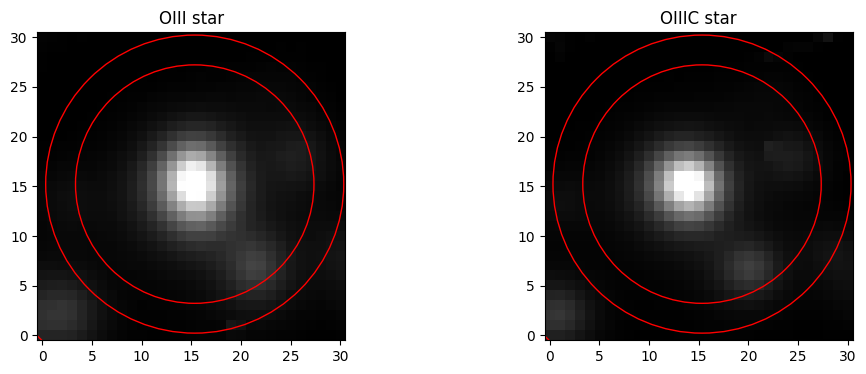

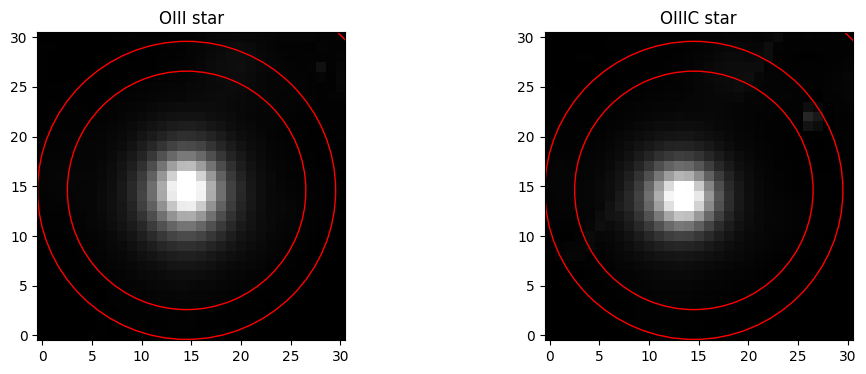

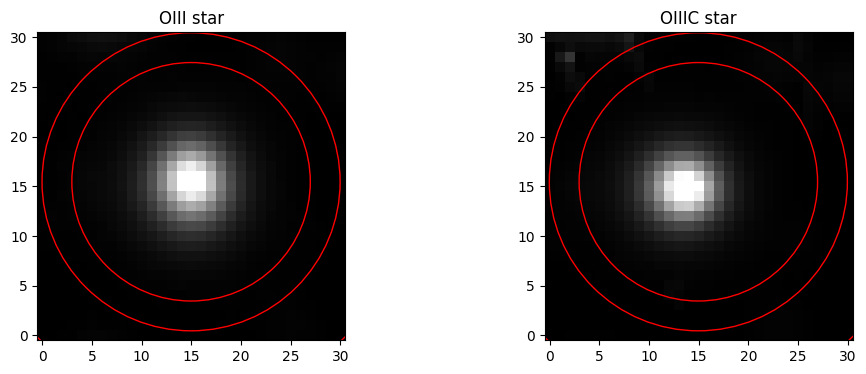

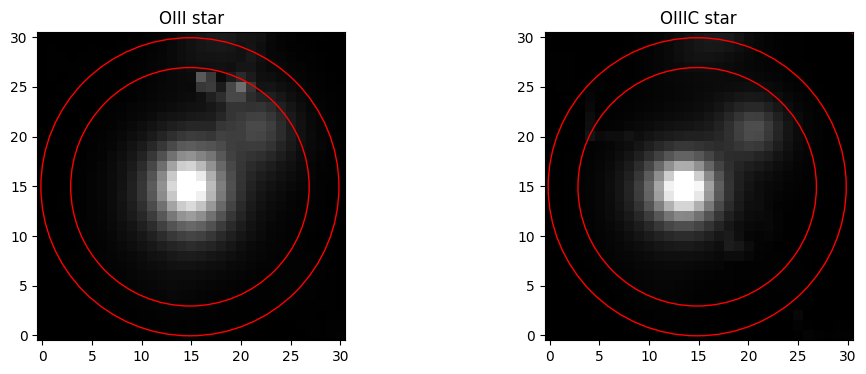

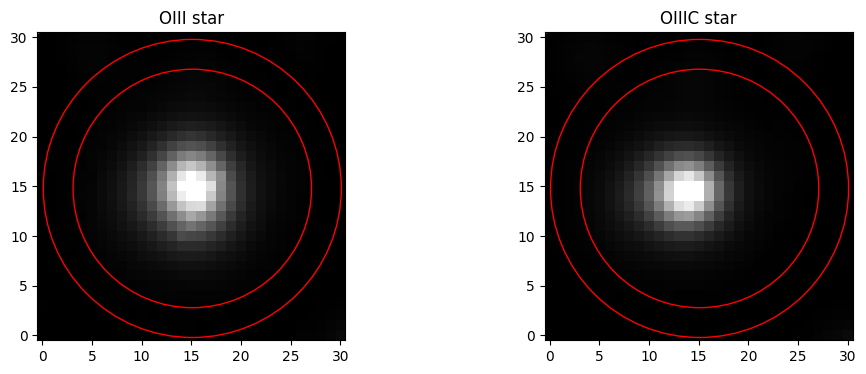

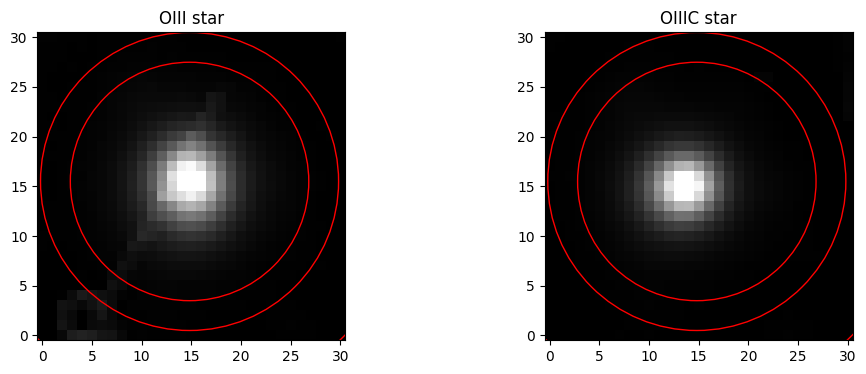

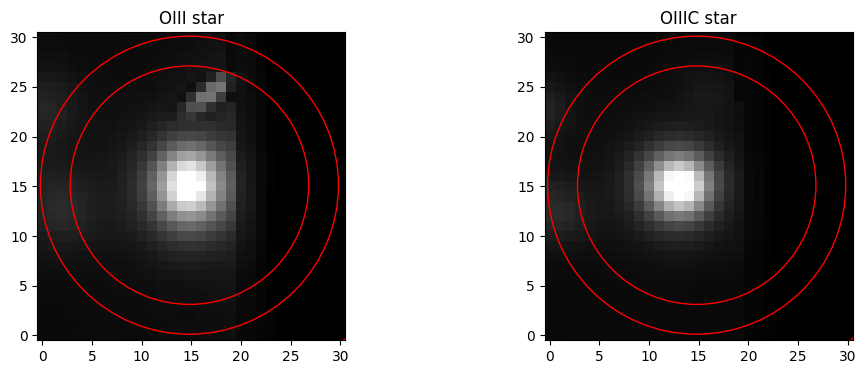

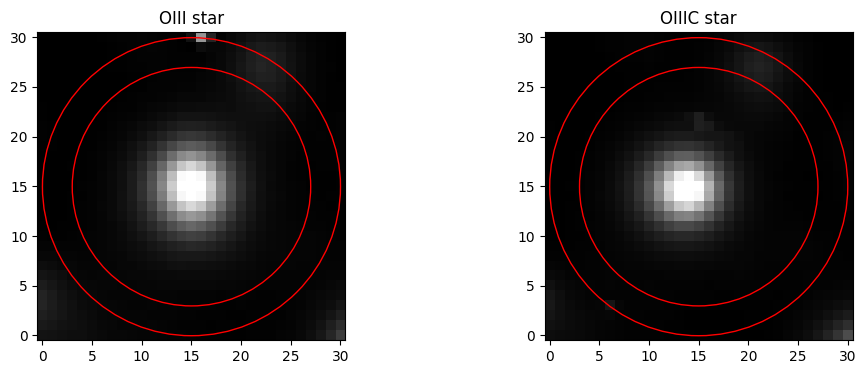

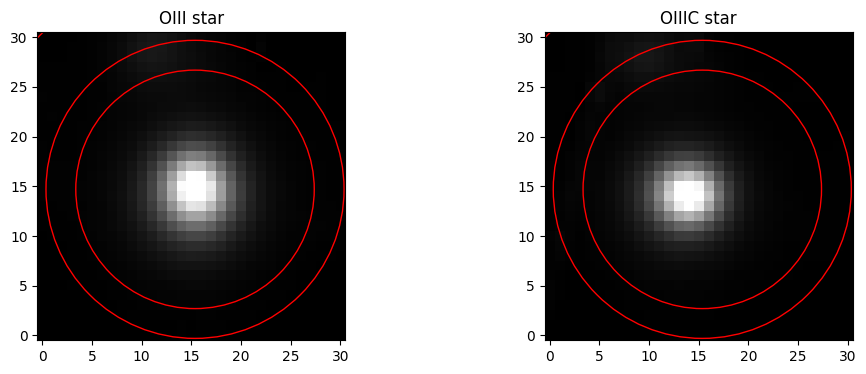

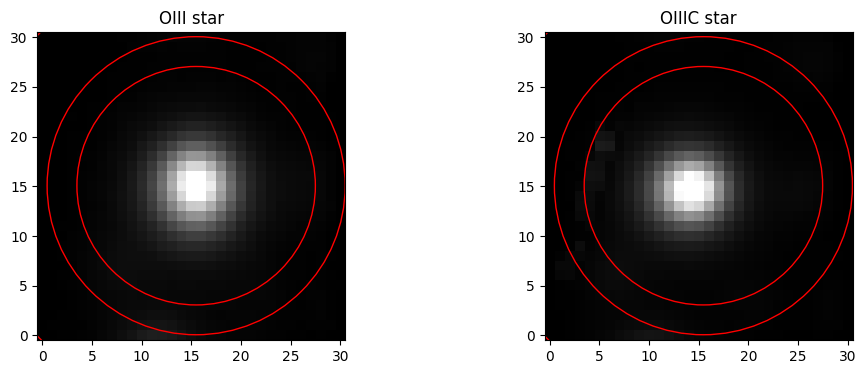

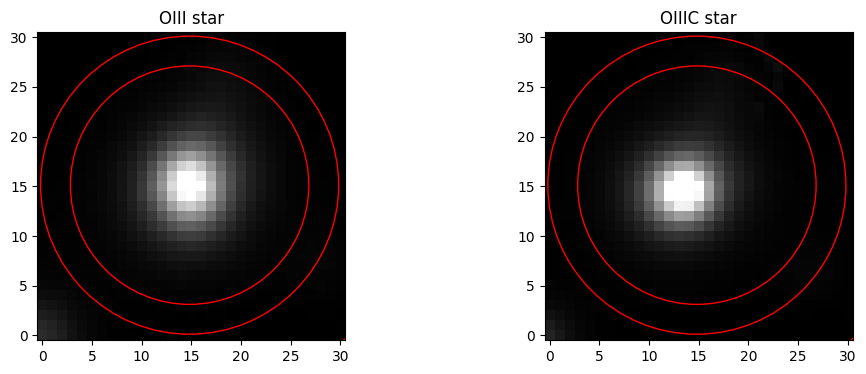

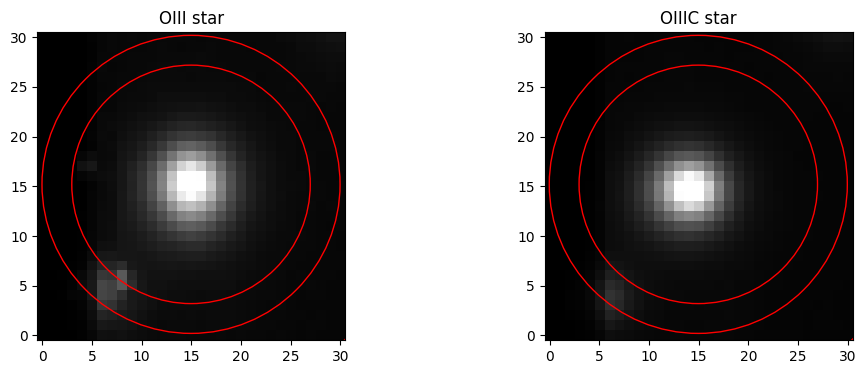

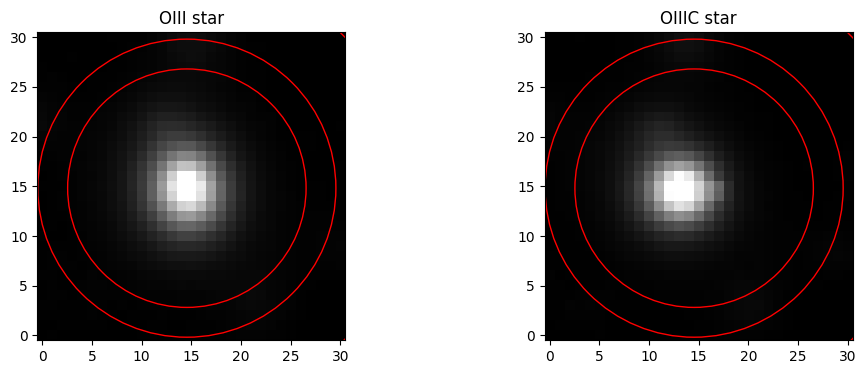

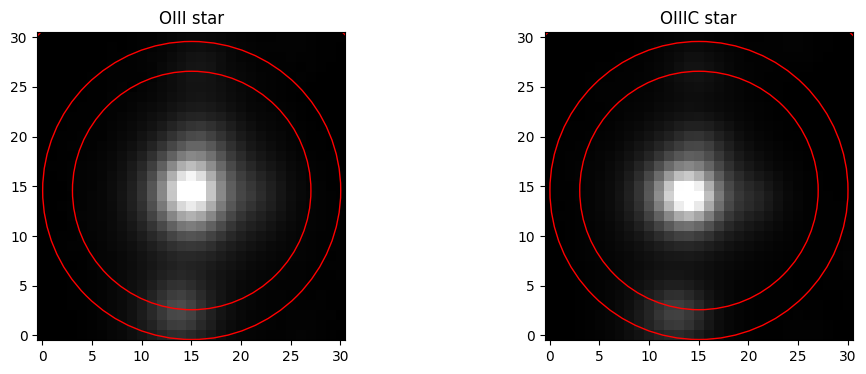

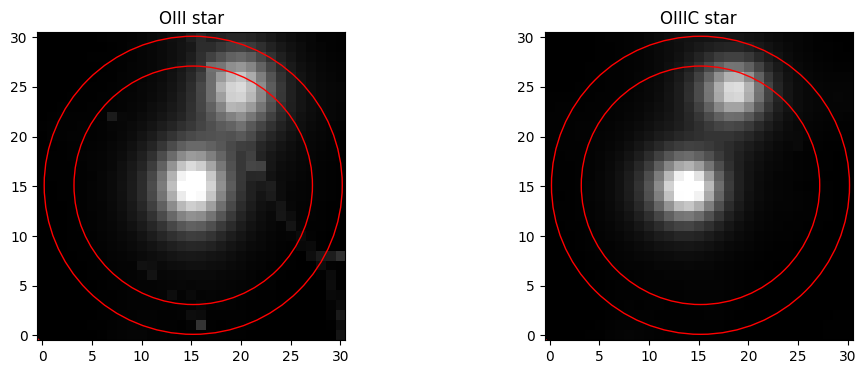

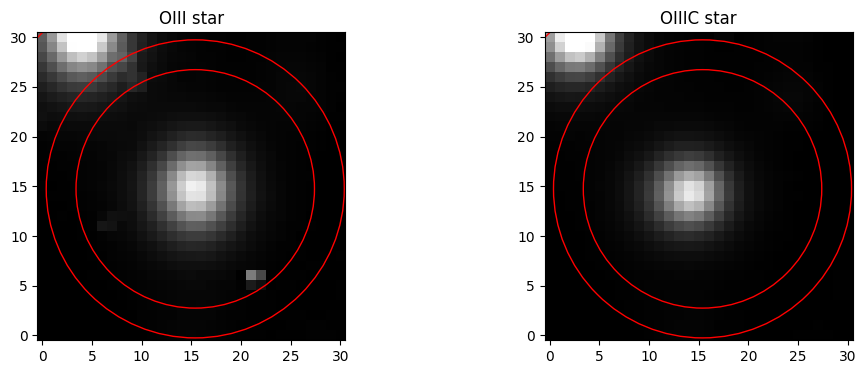

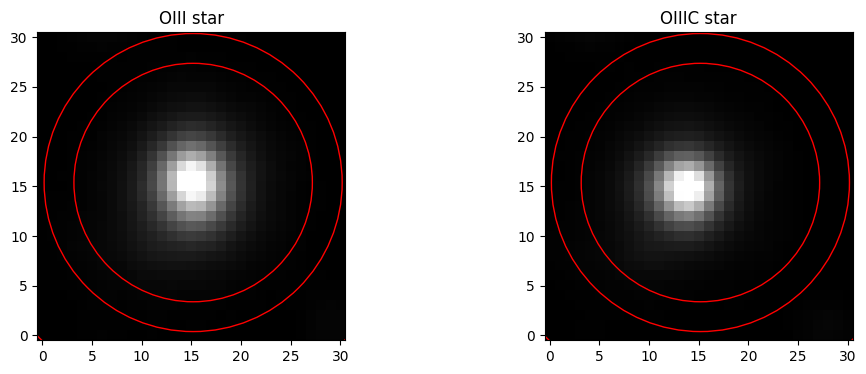

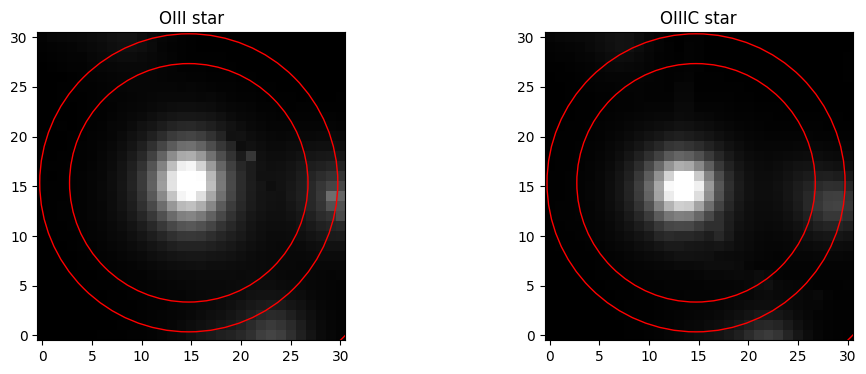

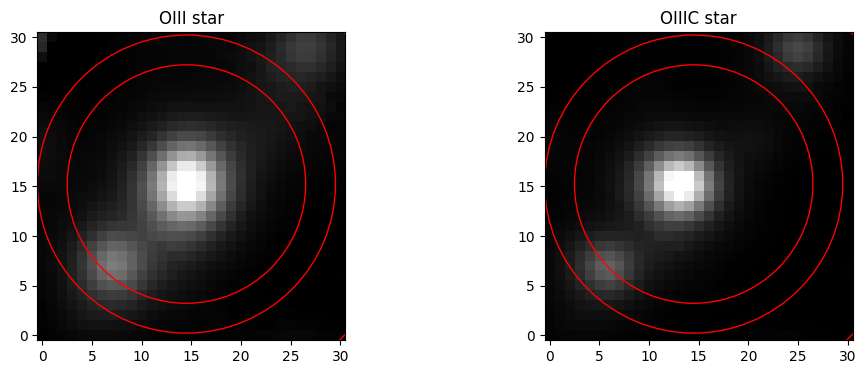

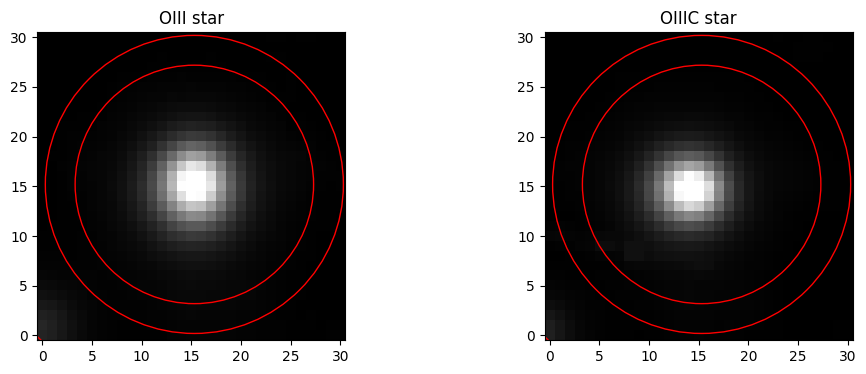

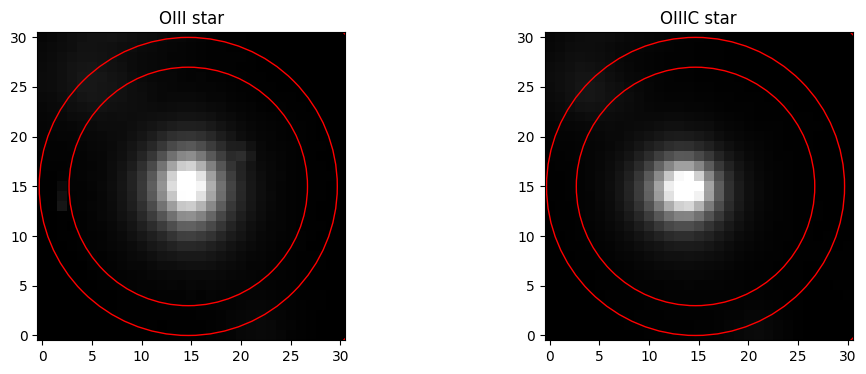

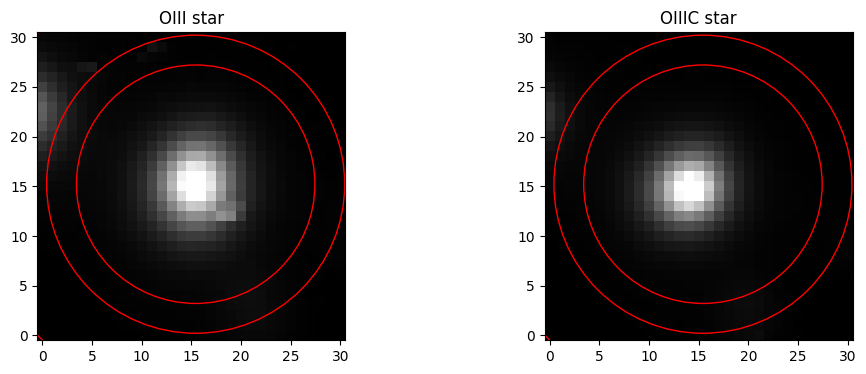

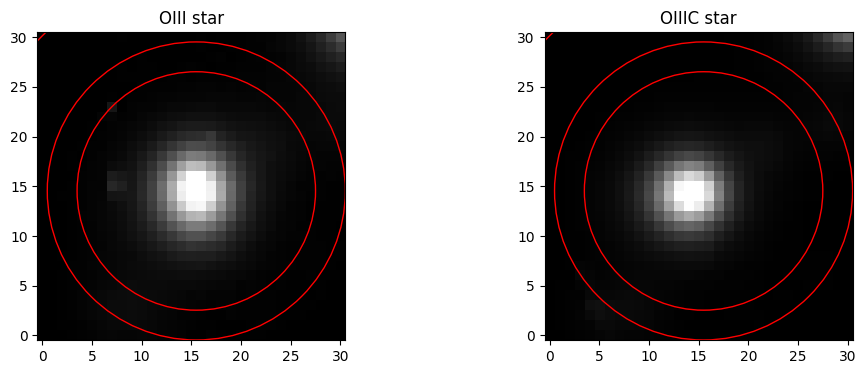

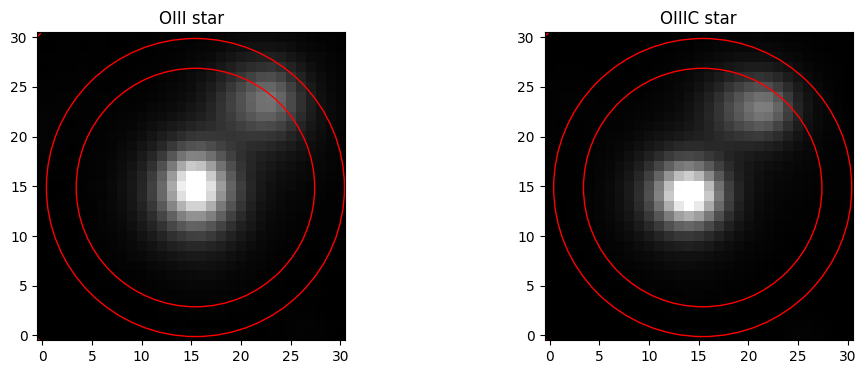

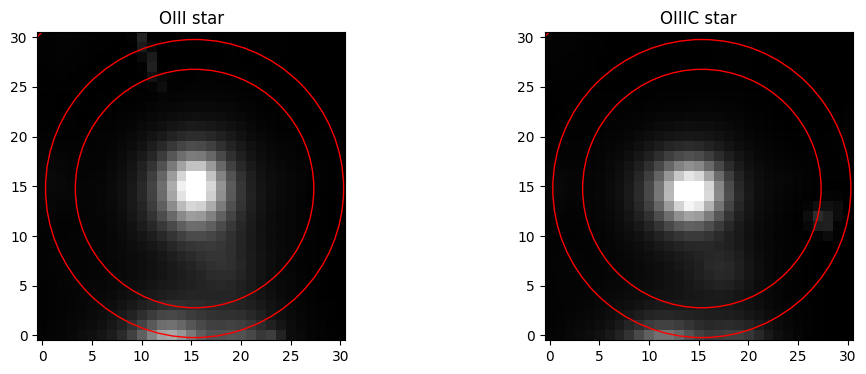

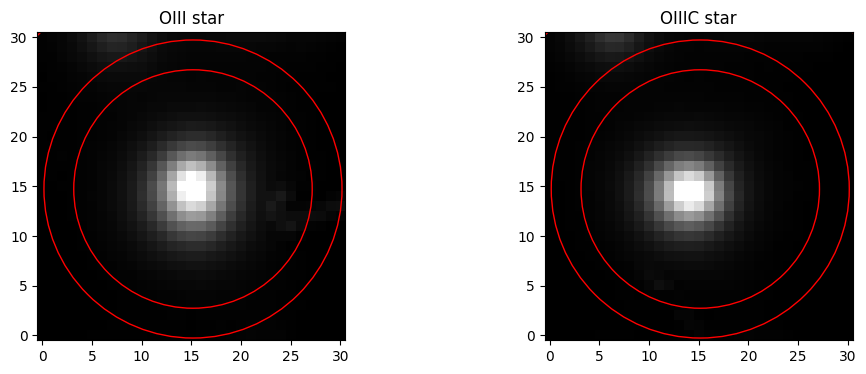

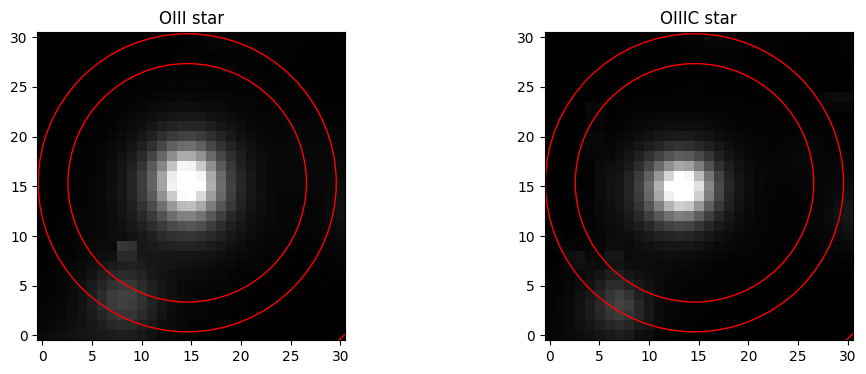

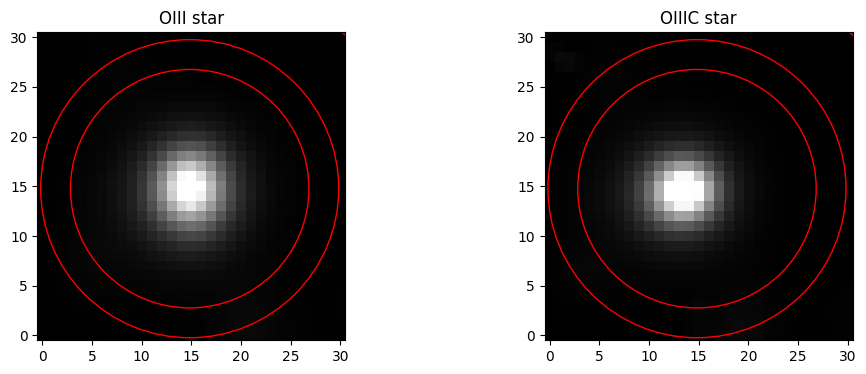

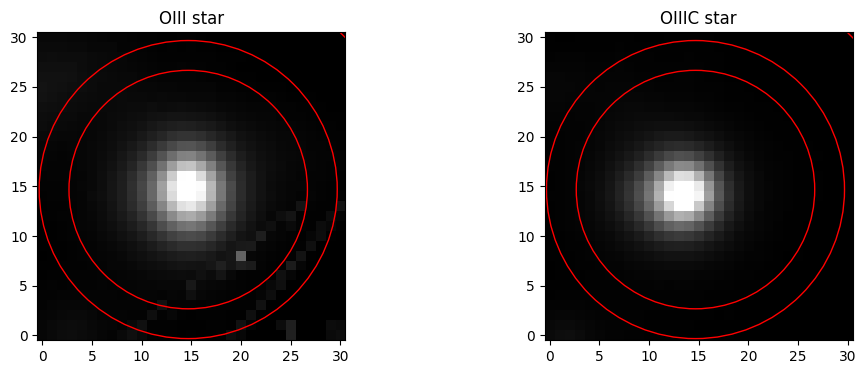

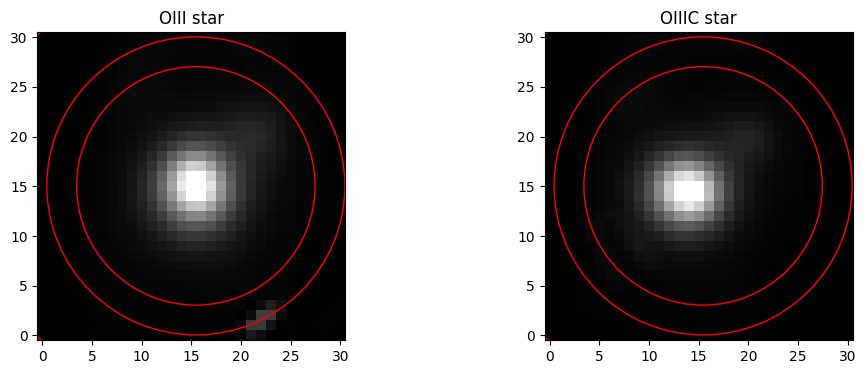

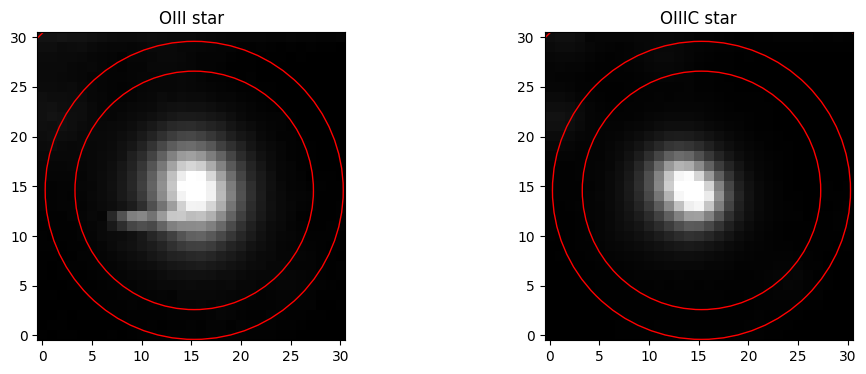

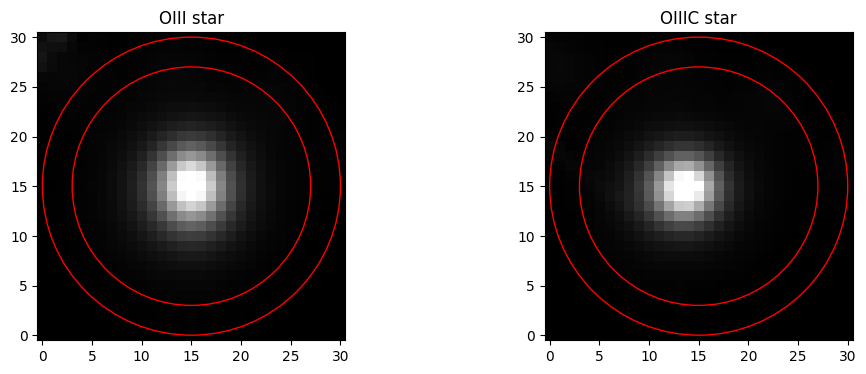

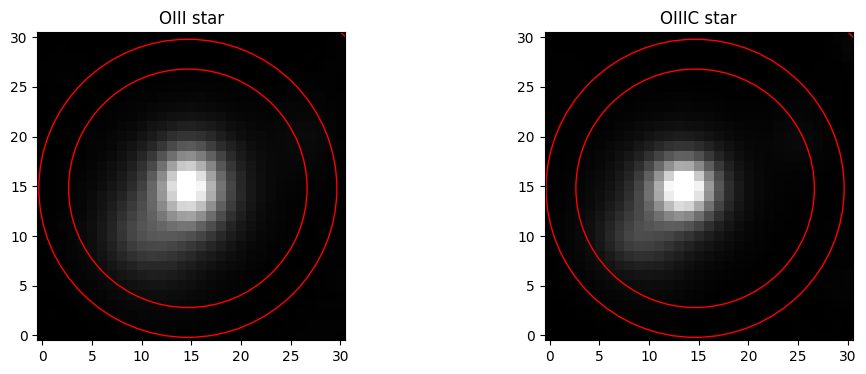

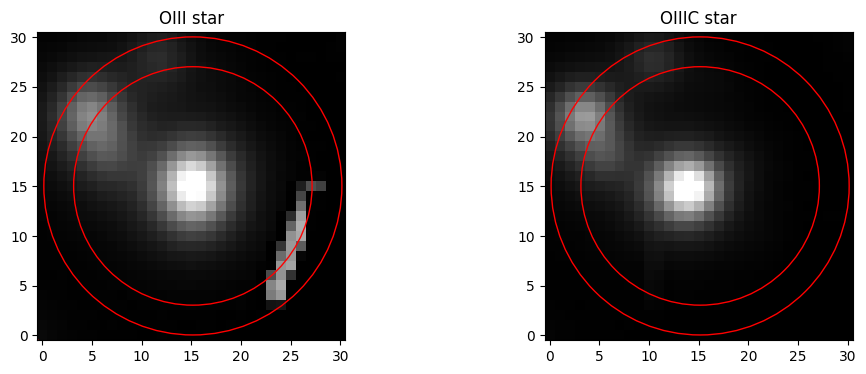

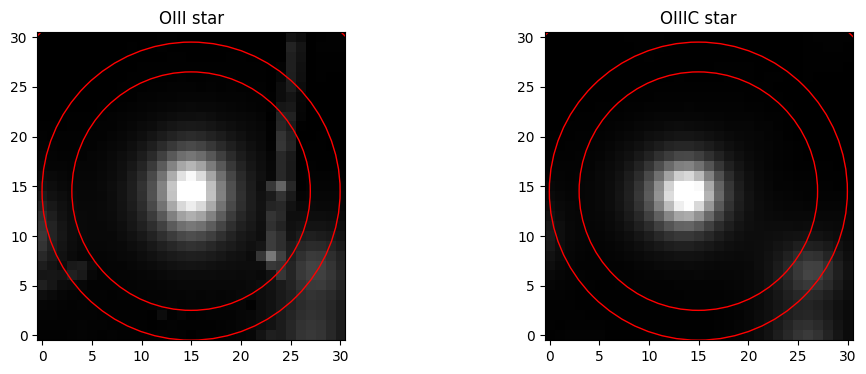

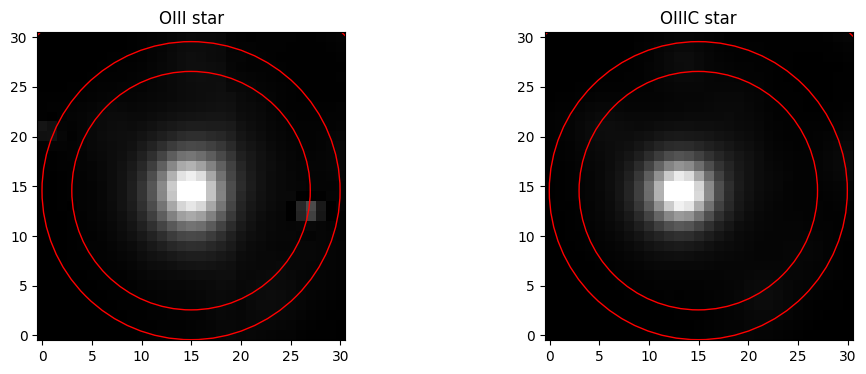

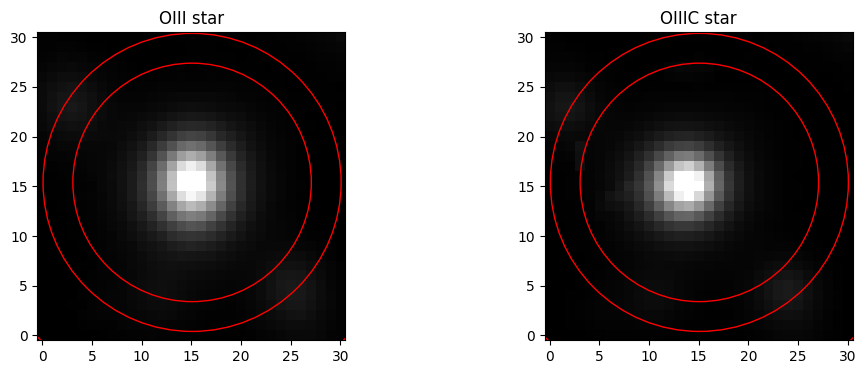

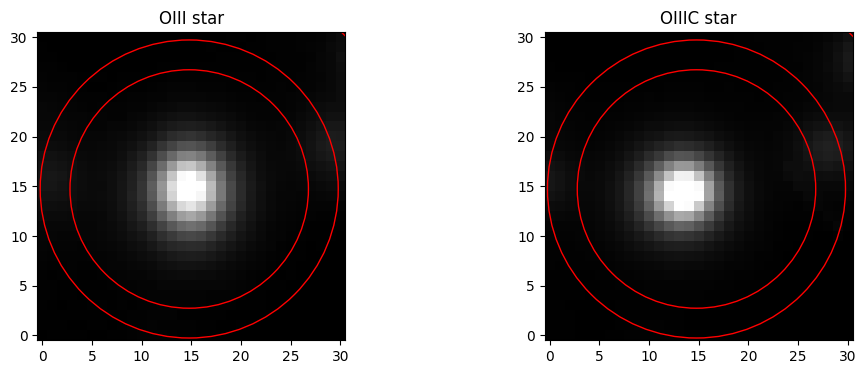

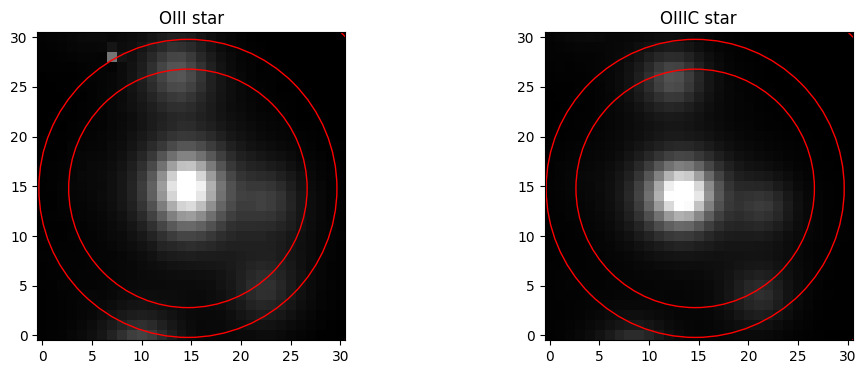

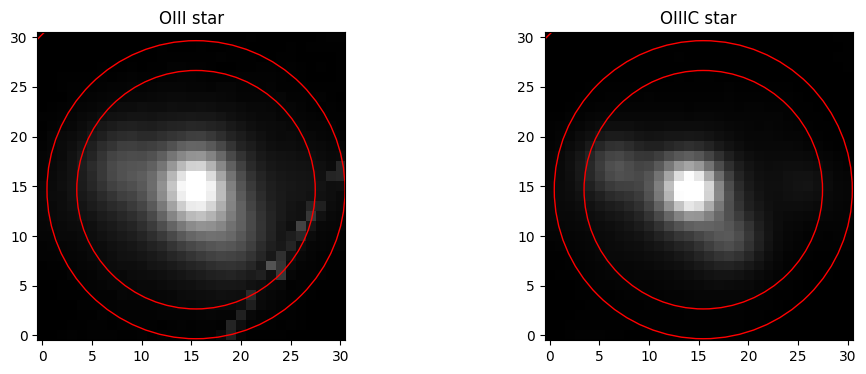

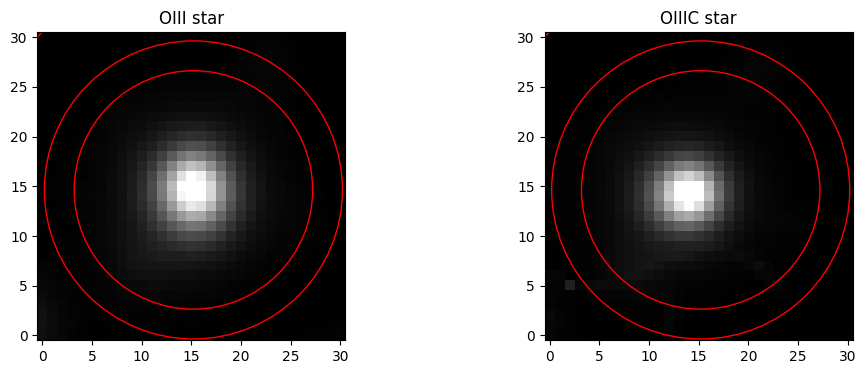

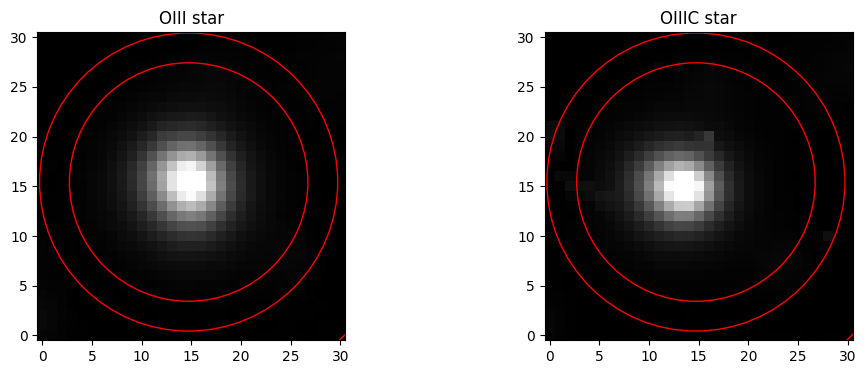

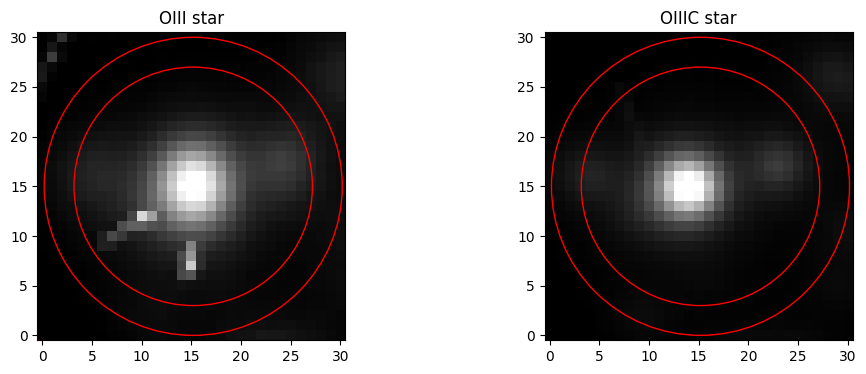

In [296]:
# cut out the detected stars and apply to both images



for star in brightest:
    
    # create cutouts for stars
    x = star["x_centroid"]
    y = star["y_centroid"]

    cutout_oiii = Cutout2D(oiii_image, (x, y), size=31)
    cutout_oiiic = Cutout2D(oiiic_image, (x, y), size=31)
    star_oiii = cutout_oiii.data
    star_oiiic = cutout_oiiic.data
    
    # oiii aperture drawing
    pos_oiii = cutout_oiii.input_position_cutout      # local cutout coords
    aperture_oiii = CircularAperture(pos_oiii, r=12)
    annulus_oiii = CircularAnnulus(pos_oiii, r_in=15, r_out=22)
    
    pos_oiiic = cutout_oiiic.input_position_cutout     # local cutout coords
    aperture_oiiic = CircularAperture(pos_oiiic, r=12)
    annulus_oiiic = CircularAnnulus(pos_oiiic, r_in=15, r_out=22)

    # aperture sum measurment
    oiii_sum = aperture_photometry(star_oiii, aperture_oiii)
    oiiic_sum = aperture_photometry(star_oiiic, aperture_oiiic)
    oiii_raw = float(oiii_sum["aperture_sum"][0])
    oiiic_raw = float(oiiic_sum["aperture_sum"][0])
    
    # background measurement
    annulus_stats_oiii = ApertureStats(star_oiii, annulus_oiii, sigma_clip=SigmaClip(sigma=3.0))
    annulus_stats_oiiic = ApertureStats(star_oiiic, annulus_oiiic, sigma_clip=SigmaClip(sigma=3.0))

    bkg_oiii = annulus_stats_oiii.median * annulus_oiii.area
    bkg_oiiic = annulus_stats_oiiic.median * annulus_oiiic.area

    # calculate net background subtracted sum
    oiii_rate = oiii_raw - bkg_oiii
    oiiic_rate = oiiic_raw - bkg_oiiic
    
    # flux ratio for subtraction factor
    flux_ratio = oiii_rate / oiiic_rate
   
    # add values to the table
    cal_table.add_row({
        "x_centroid": x * u.pix,
        "y_centroid": y * u.pix,
        "oiii_raw_sum": oiii_raw * u.electron / u.s,
        "oiiic_raw_sum": oiiic_raw * u.electron / u.s,
        "oiii_rate": oiii_rate * u.electron / u.s,
        "oiiic_rate": oiiic_rate * u.electron / u.s,
        "flux_ratio": flux_ratio
    })
   
   
   
   
   
   
   
    # plot star previews
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(star_oiii, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiii, 5), vmax=np.nanpercentile(star_oiii, 99.5))
    ax1.set_title("OIII star")

    ax2.imshow(star_oiiic, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiiic, 5), vmax=np.nanpercentile(star_oiiic, 99.5))
    ax2.set_title("OIIIC star")

    aperture_oiii.plot(ax=ax1, color="red")
    annulus_oiii.plot(ax=ax1, color="red")
    aperture_oiiic.plot(ax=ax2, color="red")
    annulus_oiii.plot(ax=ax2, color="red")


    plt.show()


In [297]:
df = cal_table.to_pandas()
df

,x_centroid,y_centroid,oiii_raw_sum,oiiic_raw_sum,oiii_rate,oiiic_rate,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,separation,flux_ratio,simulated_ratio,simulated_oiii_flux,simulated_oiiic_flux
0,1230.733929,889.336016,2088.434594,3140.645213,1949.412094,2888.580653,0.0,0.0,0,0.0,0.0,,0.0,0.674869,0.0,0.0,0.0
1,811.205426,604.520964,1428.152045,2588.768327,1340.856603,2409.764610,0.0,0.0,0,0.0,0.0,,0.0,0.556426,0.0,0.0,0.0
2,932.757145,534.819993,1109.593914,2212.500426,1032.810708,2061.434017,0.0,0.0,0,0.0,0.0,,0.0,0.501016,0.0,0.0,0.0
3,643.651202,1416.274626,578.102620,1366.659626,502.434568,1212.599328,0.0,0.0,0,0.0,0.0,,0.0,0.414345,0.0,0.0,0.0
4,1364.849469,69.289549,272.510097,691.389767,233.936063,601.340128,0.0,0.0,0,0.0,0.0,,0.0,0.389025,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1242.653485,418.787370,84.091217,224.140048,43.870355,136.549019,0.0,0.0,0,0.0,0.0,,0.0,0.321279,0.0,0.0,0.0
146,1363.470291,2129.655515,85.632927,197.539329,50.834890,125.300362,0.0,0.0,0,0.0,0.0,,0.0,0.405704,0.0,0.0,0.0
147,1853.209346,924.632076,68.721583,171.310196,35.705651,100.403827,0.0,0.0,0,0.0,0.0,,0.0,0.355620,0.0,0.0,0.0
148,1765.729324,409.428317,67.141837,153.644839,33.405060,83.608281,0.0,0.0,0,0.0,0.0,,0.0,0.399542,0.0,0.0,0.0


In [298]:
# compute median scale factor for image subtraction
np.nanmedian(cal_table["flux_ratio"])

0.39077654992386607

In [299]:
# lookup Gaia stats for each star in the table

radius = 2/3600 # 2 arcsec

for i, row in enumerate(cal_table):
    
    x = row["x_centroid"]
    y = row["y_centroid"]
    coord = wcs.pixel_to_world(x, y)
    
    
    query = f"""
    SELECT TOP 1 g.source_id, g.ra, g.dec, g.phot_bp_mean_mag, ap.teff_gspphot, ap.spectraltype_esphs,
    DISTANCE(
            POINT('ICRS', g.ra, g.dec),
            POINT('ICRS', {coord.ra.deg}, {coord.dec.deg})
        ) AS separation
    FROM gaiadr3.gaia_source AS g
    LEFT OUTER JOIN gaiadr3.astrophysical_parameters AS ap
    ON g.source_id = ap.source_id
    WHERE 1 = CONTAINS(
    POINT('ICRS', g.ra, g.dec),
    CIRCLE(
        'ICRS',
        {coord.ra.deg},
        {coord.dec.deg},
        {radius}
        )
    )
    ORDER BY separation ASC
    """
    
    job = Gaia.launch_job(query)
    result = job.get_results()
    
    
    if len(result) > 0:
        
        match = result[0]
        cal_table["ra"][i] = match["ra"] * u.deg
        cal_table["dec"][i] = match["dec"] * u.deg
        cal_table["source_id"][i] = int(match["SOURCE_ID"])
        cal_table["phot_bp_mean_mag"][i] = match["phot_bp_mean_mag"] * u.mag
        cal_table["teff_gspphot"][i] = match["teff_gspphot"] * u.K
        cal_table["spectraltype_esphs"][i] = match["spectraltype_esphs"]
        cal_table["separation"][i] = (match["separation"] * u.deg).to(u.arcsec)
    
    # print(f"{i + 1}/{len(cal_table)} done", end="\r", flush=True)
    # print(result)
    print(f"\r{i + 1}/{len(cal_table)} done", end="", flush=True)
print()
    

150/150 done


In [300]:
df = cal_table.to_pandas()
df

,x_centroid,y_centroid,oiii_raw_sum,oiiic_raw_sum,oiii_rate,oiiic_rate,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,separation,flux_ratio,simulated_ratio,simulated_oiii_flux,simulated_oiiic_flux
0,1230.733929,889.336016,2088.434594,3140.645213,1949.412094,2888.580653,86.941278,-70.398233,4656999405200489984,13.614061,5709.821777,F,1.020323,0.674869,0.0,0.0,0.0
1,811.205426,604.520964,1428.152045,2588.768327,1340.856603,2409.764610,86.919209,-70.376929,4656999542639412480,14.214470,5459.562012,G,0.964057,0.556426,0.0,0.0,0.0
2,932.757145,534.819993,1109.593914,2212.500426,1032.810708,2061.434017,86.906084,-70.381336,4656999508279668992,14.458078,5764.995117,K,0.954211,0.501016,0.0,0.0,0.0
3,643.651202,1416.274626,578.102620,1366.659626,502.434568,1212.599328,87.028780,-70.379017,4656999675756956544,15.241419,5944.969727,G,0.639680,0.414345,0.0,0.0,0.0
4,1364.849469,69.289549,272.510097,691.389767,233.936063,601.340128,86.831825,-70.394552,4657000195474396672,16.097672,6036.355957,F,1.450019,0.389025,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1242.653485,418.787370,84.091217,224.140048,43.870355,136.549019,86.880631,-70.393302,4656999469638289536,17.297859,4402.686523,M,1.105128,0.321279,0.0,0.0,0.0
146,1363.470291,2129.655515,85.632927,197.539329,50.834890,125.300362,87.095021,-70.418163,4656996312809356928,0.000000,0.000000,,0.480493,0.405704,0.0,0.0,0.0
147,1853.209346,924.632076,68.721583,171.310196,35.705651,100.403827,86.923764,-70.425063,4656993495307007616,0.000000,0.000000,,0.503786,0.355620,0.0,0.0,0.0
148,1765.729324,409.428317,67.141837,153.644839,33.405060,83.608281,86.861445,-70.415688,4656993525364271872,17.944401,0.000000,,1.343913,0.399542,0.0,0.0,0.0


In [301]:
cal_table.write("calibration_table_backup.fits", overwrite=True)

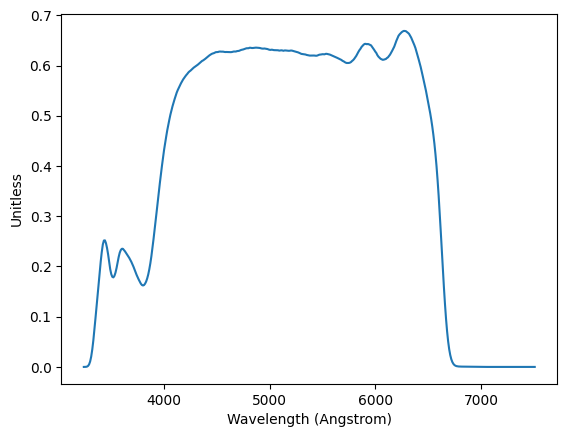

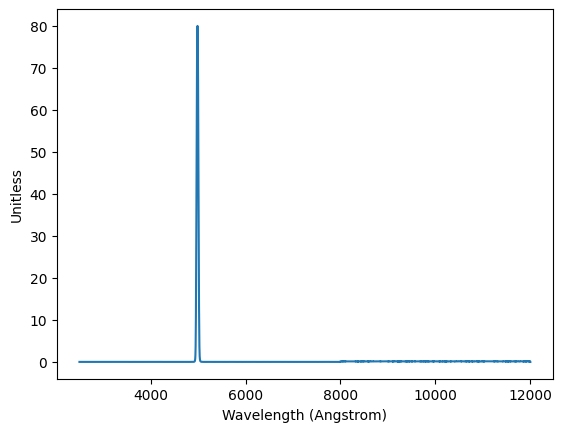

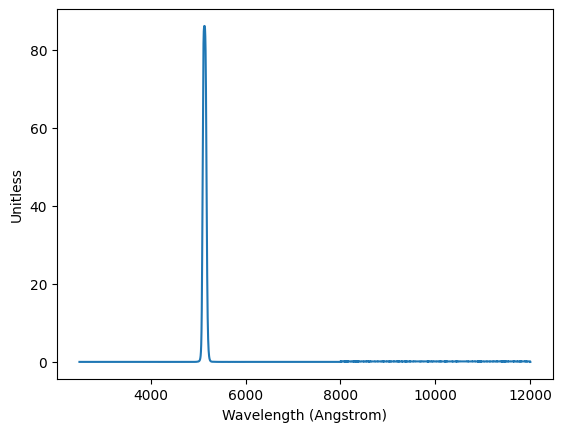

In [302]:
# import all filters for scaling and integration

gaia_bp = SpectralElement.from_file("filters/gaia_bp.fits")
gaia_bp.plot()

gmos_oiii = SpectralElement.from_file("filters/gmos_oiii.fits")
gmos_oiii.plot()

gmos_oiiic = SpectralElement.from_file("filters/gmos_oiiic.fits")
gmos_oiiic.plot()


In [303]:
# create the full columns for storing the simulated flux and ratios
#TODO: fix the dict design at the top for the table

In [304]:
# calculate the simulated flux for each star

# vega source for magnitude conversion
vega = SourceSpectrum.from_vega()
 
# use this since pickles is more precise than just a class type
spectral_map = {
    "A": "a5v",
    "B": "b57v",
    "F": "f5v",
    "G": "g5v",
    "K": "k5v",
    "M": "m5v",
}


for i, row in enumerate(cal_table):
    

    spectral_class = cal_table["spectraltype_esphs"][i].strip().upper()
    bp_mag = cal_table["phot_bp_mean_mag"][i].to_value(u.mag)

    spec_name = spectral_map.get(spectral_class)

    if spec_name is None:
        print("skip this entry no type available")
        
    else:
        spectrum = Spextrum(f"pickles/{spec_name}")
        scaled_spectum = spectrum.normalize(bp_mag * su.VEGAMAG, band=gaia_bp, vegaspec=vega)
        
        
        obs_oiii = Observation(scaled_spectum, gmos_oiii)
        photon_flux_oiii = obs_oiii.integrate(flux_unit=su.FLAM)

        obs_oiiic = Observation(scaled_spectum, gmos_oiiic)
        photon_flux_oiiic = obs_oiiic.integrate(flux_unit=su.FLAM)
        
        simulated_ratio = photon_flux_oiii / photon_flux_oiiic

        
        # store values in the table
        
        cal_table["simulated_oiii_flux"][i] = photon_flux_oiii
        cal_table["simulated_oiiic_flux"][i] = photon_flux_oiiic
        cal_table["simulated_ratio"][i] = simulated_ratio
        

        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead

skip this entry no type available
skip this entry no type available


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


skip this entry no type available


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead

...

skip this entry no type available
skip this entry no type available


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead

skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available
skip this entry no type available


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


skip this entry no type available
skip this entry no type available
skip this entry no type available


In [305]:
df = cal_table.to_pandas()
df

,x_centroid,y_centroid,oiii_raw_sum,oiiic_raw_sum,oiii_rate,oiiic_rate,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,separation,flux_ratio,simulated_ratio,simulated_oiii_flux,simulated_oiiic_flux
0,1230.733929,889.336016,2088.434594,3140.645213,1949.412094,2888.580653,86.941278,-70.398233,4656999405200489984,13.614061,5709.821777,F,1.020323,0.674869,0.494201,6.237709e-11,1.262181e-10
1,811.205426,604.520964,1428.152045,2588.768327,1340.856603,2409.764610,86.919209,-70.376929,4656999542639412480,14.214470,5459.562012,G,0.964057,0.556426,0.502570,3.603058e-11,7.169260e-11
2,932.757145,534.819993,1109.593914,2212.500426,1032.810708,2061.434017,86.906084,-70.381336,4656999508279668992,14.458078,5764.995117,K,0.954211,0.501016,0.599743,2.423611e-11,4.041079e-11
3,643.651202,1416.274626,578.102620,1366.659626,502.434568,1212.599328,87.028780,-70.379017,4656999675756956544,15.241419,5944.969727,G,0.639680,0.414345,0.502570,1.399238e-11,2.784164e-11
4,1364.849469,69.289549,272.510097,691.389767,233.936063,601.340128,86.831825,-70.394552,4657000195474396672,16.097672,6036.355957,F,1.450019,0.389025,0.494201,6.332586e-12,1.281379e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1242.653485,418.787370,84.091217,224.140048,43.870355,136.549019,86.880631,-70.393302,4656999469638289536,17.297859,4402.686523,M,1.105128,0.321279,0.689266,3.730203e-12,5.411852e-12
146,1363.470291,2129.655515,85.632927,197.539329,50.834890,125.300362,87.095021,-70.418163,4656996312809356928,0.000000,0.000000,,0.480493,0.405704,0.000000,0.000000e+00,0.000000e+00
147,1853.209346,924.632076,68.721583,171.310196,35.705651,100.403827,86.923764,-70.425063,4656993495307007616,0.000000,0.000000,,0.503786,0.355620,0.000000,0.000000e+00,0.000000e+00
148,1765.729324,409.428317,67.141837,153.644839,33.405060,83.608281,86.861445,-70.415688,4656993525364271872,17.944401,0.000000,,1.343913,0.399542,0.000000,0.000000e+00,0.000000e+00


In [306]:
cal_table.write( "calibration_table_large.fits", overwrite=True)